<a href="https://colab.research.google.com/github/jet0003/MSc-Dissertation/blob/main/WorkingFinalDoc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [ ]:
# Install required external packages
!pip install keras-tuner
!pip install imbalanced-learn
!pip install lime

# Core scientific stack
import pandas as pd          # Data loading and manipulation
import numpy as np           # Numerical operations
import random                # Random seed control
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns        # Statistical visualisation

# Deep learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras import layers, backend
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model

# Hyperparameter tuning
import keras_tuner as kt

# Model saving and object copying
import joblib
import copy
import os

# Scikit-learn: preprocessing, CV, metrics, classical models
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
    accuracy_score, log_loss, f1_score, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression

# Handling class imbalance
from imblearn.over_sampling import RandomOverSampler

# Explainability libraries
import shap                          # SHAP global + local attributions
from lime.lime_tabular import LimeTabularExplainer  # LIME local explanations

# Statistical testing
from scipy.stats import kruskal, spearmanr, wilcoxon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=cb454383c8a00ab6b649b75591b2943dbd7131c65669cf48df8d66b5753a72fb
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


# Seeds

In [ ]:
# --- Determinism Boot Block ---
# Ensures reproducibility across Python, NumPy, TensorFlow and data pipelines.

import os, random, numpy as np, tensorflow as tf

os.environ["PYTHONHASHSEED"] = "42"          # Fix Python hash seed
random.seed(42)                               # Python RNG
np.random.seed(42)                            # NumPy RNG
tf.random.set_seed(42)                        # TensorFlow RNG
tf.keras.utils.set_random_seed(42)            # Keras RNG
os.environ["TF_DETERMINISTIC_OPS"] = "1"      # Use deterministic TF ops
tf.config.experimental.enable_op_determinism()  # Enforce deterministic kernels

print("Determinism boot block applied: seeds fixed, ops set to deterministic.")




Determinism boot block applied: seeds fixed, ops set to deterministic.


# Data

In [ ]:
# --- Data Loading and Initial Filtering ---

# 1. Load raw pre-processed dataset
df = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Master PD Mologic Cardiff_Ann final 120416 preprocessed_82 (1).xlsx')

# 2. Remove "No Growth" samples (PathoCode = 0)
df = df[df["PathoCode"] != 0]


# --- Feature Selection ---

# Drop non-biomarker variables (IDs, survival metrics, peritonitis history, etc.)
features = df.drop(columns=[
    "PatientID", "Age (years)",
    "Days on PD censored on date of sample - peritonitis day1",
    "Episodes of peritonitis censored to sample date & to include sample.  ",
    "Tech failure on day14 (1:failure)", "Tech surv days censored on day 14",
    "Tech failure on day30 (1:failure)", "Tech surv days censored on day 30",
    "Tech failure on day90 (1:failure)", "Tech surv days censored on day 90",
    "mortality on day14 (1: mortality)", "survival days censored on day14",
    "mortality on day90 (1: mortality)", "survival days censored on day90",
    "PathoCode"
])

sample_IDs = df["PatientID"]


# --- Gram-Class Mapping ---

# Map organism codes to binary Gram class (0 = Gram-, 1 = Gram+)
mapping = {
    4: 0, 7: 0, 8: 0,   # Gram-negative
    1: 1, 2: 1, 3: 1, 5: 1, 6: 1  # Gram-positive
}

df["Gram_Class"] = df["PathoCode"].map(mapping)
y = df["Gram_Class"]


# --- Train/Test Split ---

ids_train, ids_test, X_train, X_test, Y_train, Y_test = train_test_split(
    sample_IDs, features, y,
    test_size=0.2,
    stratify=y,            # Preserve class proportions
    random_state=42
)

# Encode Gender numerically (M=0, F=1)
X_train['Gender'] = X_train['Gender'].map({'M': 0, 'F': 1})
X_test['Gender'] = X_test['Gender'].map({'M': 0, 'F': 1})

print("Train set distribution:\n", Y_train.value_counts(normalize=True))

Train set distribution:
 Gram_Class
1    0.74
0    0.26
Name: proportion, dtype: float64


# NN model

In [ ]:
def build_binary_nn(input_dim,
                    l2_reg=0.001,
                    dropout_rate=0.3,
                    learning_rate=5e-4):
    backend.clear_session()
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)), # Add Input layer
        layers.Dense(64, kernel_regularizer=l2(l2_reg)),
        layers.LeakyReLU(negative_slope=0.1),
        layers.Dropout(dropout_rate),

        layers.Dense(32, kernel_regularizer=l2(l2_reg)),
        layers.LeakyReLU(negative_slope=0.1),
        layers.Dropout(dropout_rate),

        layers.Dense(1, activation="sigmoid")
    ])
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss="binary_crossentropy",
                  metrics=["accuracy"])
    return model

# Data and Splits Info Function

In [ ]:
# Utility function to save all fold-specific data artefacts for reproducibility
def save_fold_splits(fold_num, x_train, y_train, x_test, y_test, ids_train, ids_test, ros=None):

    # --- Save original (non-oversampled) training set with patient IDs and labels ---
    train_original = x_train.copy()
    train_original["patient_id"] = ids_train.values
    train_original["label"] = y_train.values
    train_original.to_csv(f"fold_{fold_num}_train_original.csv", index=False)

    # --- Save test set with patient IDs and labels ---
    test_df = x_test.copy()
    test_df["patient_id"] = ids_test.values
    test_df["label"] = y_test.values
    test_df.to_csv(f"fold_{fold_num}_test.csv", index=False)

    # --- Record class balance before oversampling (for audit trail) ---
    y_train.value_counts(normalize=True).to_csv(f"fold_{fold_num}_class_balance_before.csv")

    # --- If RandomOverSampler is provided, generate and save oversampled training data ---
    if ros is not None:
        # Attach patient IDs to features so oversampling preserves identity mapping
        x_train_with_ids = pd.concat(
            [ids_train.reset_index(drop=True), x_train.reset_index(drop=True)], axis=1
        )

        # Apply oversampling to features + IDs together
        x_train_resampled_with_ids, y_train_res = ros.fit_resample(x_train_with_ids, y_train)

        # Separate IDs and features after oversampling
        ids_train_res = x_train_resampled_with_ids.iloc[:, 0]
        x_train_res = x_train_resampled_with_ids.iloc[:, 1:]

        # --- Save oversampled training set with patient IDs and labels ---
        train_res_df = x_train_res.copy()
        train_res_df["patient_id"] = ids_train_res.values
        train_res_df["label"] = y_train_res.values
        train_res_df.to_csv(f"fold_{fold_num}_train_ROS.csv", index=False)

        # --- Record class balance after oversampling ---
        y_train_res.value_counts(normalize=True).to_csv(f"fold_{fold_num}_class_balance_after.csv")

        # --- Save oversample mapping (IDs may appear multiple times if duplicated) ---
        pd.DataFrame({"patient_id": ids_train_res}).to_csv(
            f"fold_{fold_num}_oversample_map.csv", index=False
        )

        return train_res_df

    # Return original splits if no oversampling was applied
    return train_original, test_df

# Get predicitons and Metrics Function

In [ ]:
def evaluate_model(model=None, x_test=None, y_test=None, fold_num=None, ids = None, y_pred_proba=None):
    """
    Evaluate a model on test set and return predictions and metrics

    Parameters
    model: fitted model, if predictions are not provided
    x_test: DataFrame of features
    y_test: series of true labels
    fold_num: int or str, fold identifier
    ids: series or arrays of patient IDs (optional)
    y_pred_proba: array, (optional- is the probabilities)

    Returns
    preds_df: dataframe with patient_id, fold, ture, pred, prob
    metrics: dict
    """

    # Get probabilities if they are not passed in
    if y_pred_proba is None:
      # Predictions
      y_pred_proba = model.predict(x_test).flatten()

    # binary preds
    y_pred = (y_pred_proba > 0.5).astype(int)

    ## Save Predictions
    predictions_df = pd.DataFrame({"fold": fold_num,
                                   "true": y_test.values,
                                   "pred": y_pred,
                                   "prob": y_pred_proba})
    # Add patient IDs if provided
    if ids is not None:
      predictions_df.insert(0, "patient_id", ids.values)

    predictions_df.to_csv(f"fold{fold_num}_predictions.csv", index=False)

    # Metrics
    metrics = {
        "fold": fold_num,
        "accuracy": accuracy_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "auc": roc_auc_score(y_test, y_pred_proba),
        "logloss": log_loss(y_test, y_pred_proba)
    }
    # confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    pd.DataFrame(cm).to_csv(f"fold_{fold_num}_confusion_matrix.csv", index=False)

    # ROC curve
    # PR curve

    return predictions_df, metrics

# Train a model function

In [ ]:
# Train a neural network for a single cross-validation fold
# Handles model construction, early stopping, training, and saving artefacts
def train_model(x_train, y_train, x_test, y_test, fold_num, input_dim,
                batch_size=16, epochs=100, patience=20):

    # --- Build a fresh model for this fold ---
    model = build_binary_nn(input_dim=input_dim)

    # --- Early stopping to prevent overfitting ---
    stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True
    )

    # --- Train the model on the fold-specific data ---
    history = model.fit(
        x_train, y_train,
        validation_data=(x_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[stop],
        verbose=1
    )

    # --- Save training history for diagnostics ---
    pd.DataFrame(history.history).to_csv(
        f"fold_{fold_num}_training_history.csv", index=False
    )

    # --- Save the trained model for this fold ---
    model.save(f"model_{fold_num}.keras")

    return model

# SHAP Function

## Compute SHAP values

In [ ]:
# Compute SHAP values for a trained model on a given fold
# Returns raw SHAP arrays, the Explanation object, and a tidy DataFrame
def compute_shap_values(model, x_train, x_test, feature_names=None, fold_num=None):

    # --- Use training feature names if none are provided ---
    if feature_names is None:
        feature_names = x_train.columns

    # --- Background dataset for SHAP (model's reference distribution) ---
    background = x_train

    # --- Wrapper to ensure SHAP calls the model correctly ---
    f = lambda x: model.predict(x)[:, 0]

    # --- Build SHAP explainer with reproducibility controls ---
    explainer = shap.Explainer(
        f,
        background,
        seed=42,   # ensures deterministic SHAP behaviour
        feature_names=x_test.columns if hasattr(x_test, "columns") else None
    )

    # --- Compute SHAP values for the test set ---
    explanation_shap = explainer(x_test)

    # --- Extract SHAP values as a NumPy array ---
    shap_values = explanation_shap.values

    # --- Convert SHAP values to a DataFrame for easier analysis ---
    shap_df = pd.DataFrame(shap_values, columns=feature_names)
    shap_df["fold"] = fold_num

    return shap_df, shap_values, explanation_shap

## Plot Charts

In [ ]:
# --- SHAP Global Feature Importance Bar Plot ---
def plot_shap_bar(shap_values, feature_names, fold_num=None):
    """Plot global mean absolute SHAP values as a bar chart."""

    # --- Compute mean absolute SHAP values for global importance ---
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    # --- Rank features by importance ---
    importance_ranking = sorted(
        zip(feature_names, mean_abs_shap),
        key=lambda x: x[1],
        reverse=True
    )
    features_sorted, values_sorted = zip(*importance_ranking)

    # --- Plot bar chart ---
    plt.figure(figsize=(20, 16))
    plt.bar(features_sorted, values_sorted, width=0.8)
    plt.title("Global Feature Importance (bar)")
    plt.ylabel("Mean Absolute SHAP Value")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

    # --- Return tidy ranking DataFrame for later aggregation ---
    return pd.DataFrame({
        "fold": fold_num,
        "feature": features_sorted,
        "mean_abs_shap": values_sorted,
        "rank": range(1, len(features_sorted) + 1)
    })


In [ ]:
# --- SHAP Beeswarm Plot (Feature Impact Distribution) ---
def plot_shap_beeswarm(shap_values, x_data, feature_names):
    """Plot SHAP beeswarm showing distribution of feature impacts."""

    plt.figure(figsize=(20, 16))
    shap.summary_plot(
        shap_values,
        x_data,
        feature_names=feature_names,
        show=False
    )
    plt.title("Feature Impact Distribution (beeswarm)")
    plt.tight_layout()
    plt.show()




In [ ]:
# --- SHAP Dependence Plot (Feature Interaction / Effect Curve) ---
def plot_shap_dependence(feature_name, shap_values, X_data):
    """Plot SHAP dependence for a single feature."""

    shap.dependence_plot(feature_name, shap_values, X_data)
    plt.show()


In [ ]:
# --- SHAP Waterfall Plot (Local Explanation for One Patient) ---
def plot_shap_waterfall(explanation, preds_df, patient_id, title_prfix="Feature impacts"):
    """Plot a SHAP waterfall explanation for a specific patient."""

    # --- Identify the row corresponding to the selected patient ---
    idx = preds_df.index[preds_df["patient_id"] == patient_id][0]

    # --- Plot waterfall explanation ---
    shap.plots.waterfall(explanation[idx])
    plt.show()



# Permutation Importance

## compute feature shuffling

In [ ]:
def compute_permutation_importance(
    X_val, y_val, baseline_metrics, evaluate_fn, ids,
    fold_num=None, model=None, models=None,
    ensemble_predict_fn=None
):
    """
    Compute permutation importance for either a single model or an ensemble.

    Parameters
    ----------
    X_val : DataFrame
        Validation features for the fold.
    y_val : Series
        True labels for the validation set.
    baseline_metrics : dict
        Metrics computed on the unshuffled validation set (auc, f1, logloss).
    evaluate_fn : callable
        Function used to compute metrics given predictions.
    ids : Series
        Patient IDs for the validation set.
    fold_num : int or str, optional
        Fold identifier.
    model : object, optional
        Trained model for single‑model permutation importance.
    models : list, optional
        List of models for ensemble permutation importance.
    ensemble_predict_fn : callable, optional
        Function that returns ensemble probability predictions.

    Returns
    -------
    DataFrame
        One row per feature containing baseline metrics, shuffled metrics,
        and the metric drops (importance scores).
    """

    perm_results = []

    for feature in X_val.columns:

        # --- Shuffle one feature at a time ---
        X_shuffled = X_val.copy()
        X_shuffled[feature] = np.random.permutation(X_shuffled[feature].values)

        # --- Ensemble mode ---
        if models is not None and ensemble_predict_fn is not None:
            y_pred_proba_shuffled = ensemble_predict_fn(models, X_shuffled)
            _, metrics_shuffled = evaluate_fn(
                y_test=y_val,
                y_pred_proba=y_pred_proba_shuffled,
                fold_num="ensemble",
                ids=ids
            )

        # --- Single‑model mode ---
        else:
            _, metrics_shuffled = evaluate_fn(
                model, X_shuffled, y_val, fold_num, ids=ids
            )

        # --- Store results for this feature ---
        perm_results.append({
            "feature": feature,
            "baseline_auc": baseline_metrics["auc"],
            "shuffled_auc": metrics_shuffled["auc"],
            "auc_drop": baseline_metrics["auc"] - metrics_shuffled["auc"],

            "baseline_f1": baseline_metrics["f1"],
            "shuffled_f1": metrics_shuffled["f1"],
            "f1_drop": baseline_metrics["f1"] - metrics_shuffled["f1"],

            "baseline_logloss": baseline_metrics["logloss"],
            "shuffled_logloss": metrics_shuffled["logloss"],
            "logloss_drop": baseline_metrics["logloss"] - metrics_shuffled["logloss"],

            "fold": fold_num
        })

    return pd.DataFrame(perm_results)

# LIME

## LIME Explainer

In [ ]:
def build_lime_explainer(X_train, feature_names, class_names=["Negative", "Positive"]):
  """Initialise a LIME tabular explainer"""
  return LimeTabularExplainer(
      training_data=np.array(X_train),
      feature_names=feature_names,
      class_names=class_names,
      mode="classification"
  )

## LIME plots

In [ ]:
def plot_lime_for_patient(explainer, model, X_data, preds_df, patient_id, num_features=8):
  """Generate and plot a LIME explanation for a single patient"""

  # find patient idx

  idx = preds_df.index[preds_df["patient_id"] == patient_id][0]
  x_instance = X_data.iloc[idx].values.reshape(1, -1)

  # Run LIME

  expl = explainer.explain_instance(
      X_data.iloc[idx].values,
      model.predict,
      num_features=num_features,
      top_labels=1
  )

  # Align explanation with predicted label
  pred_label = np.argmax(model.predict(x_instance))
  fig = expl.as_pyplot_figure(label=pred_label)
  plt.title(f"LIME explanation for Patient {patient_id}")
  plt.show()

  return expl

In [ ]:
def plot_lime_for_pairs(explainer, model, X_data, preds_df, pairs_df, num_features=8):
  """Generate and plot a LIME explanation for patient pairs (NNs)"""

  for _, row in pairs_df.iterrows():
    for pid in [row["i"], row["j"]]:
      idx = preds_df.index[preds_df["patient_id"] == pid][0]
      x_instance = X_data.iloc[idx].values.reshape(1, -1)

       # Run LIME

      expl = explainer.explain_instance(
        X_data.iloc[idx].values,
        model.predict,
        num_features=num_features,
        top_labels=1
      )

    # Align explanation with predicted label
    pred_label = np.argmax(model.predict(x_instance))
    fig = expl.as_pyplot_figure(label=pred_label)
    plt.title(f"{row['category']} pair (distance={row['distance']:.2f}) - Patient {pid}")
    plt.show()

  return expl

# Statistical Tests

## Kruskal-Wallis

In [ ]:
def compute_kruskal_shap(feature_names, all_shap=None, final_shap=None, absolute=False):
    """
    Perform a Kruskal–Wallis test to assess whether the distribution of SHAP
    values for each feature differs significantly across folds (fold mode) or
    between the ensemble and folds (ensemble mode).

    Parameters
    ----------
    feature_names : list
        List of feature names to test.
    all_shap : list of DataFrames, optional
        List of fold-level SHAP DataFrames (one per fold).
    final_shap : DataFrame, optional
        Long-format SHAP DataFrame containing both fold and ensemble rows.
    absolute : bool, default=False
        If True, use absolute SHAP values; otherwise use signed SHAP values.

    Returns
    -------
    DataFrame
        One row per feature containing the Kruskal–Wallis statistic and p-value.
    """

    results_kw = []

    for feature in feature_names:

        # --- Fold-level mode ---
        if all_shap is not None:
            distributions = [
                df[feature].abs().values if absolute else df[feature].values
                for df in all_shap
            ]

        # --- Ensemble mode ---
        elif final_shap is not None:
            distributions = [
                group[feature].abs().values if absolute else group[feature].values
                for _, group in final_shap.groupby("fold")
            ]

        else:
            raise ValueError("Either all_shap (fold mode) or final_shap (ensemble mode) must be provided.")

        # --- Kruskal–Wallis test ---
        stat, p = kruskal(*distributions)

        results_kw.append({
            "feature": feature,
            "statistic": stat,
            "p_value": p
        })

    df = pd.DataFrame(results_kw)

    # Sort by significance if using absolute SHAP values
    if absolute:
        df = df.sort_values("p_value", ascending=True)

    return df

## Spearman Rank

In [ ]:
def compute_feature_rank_stability(all_rankings):
    """
    Compute fold-to-fold stability of feature rankings using Spearman correlation.

    Parameters
    ----------
    all_rankings : list of DataFrames
        Each DataFrame contains feature rankings for one fold
        with columns: ["feature", "rank", "fold"].

    Returns
    -------
    DataFrame
        A fold-by-fold Spearman correlation matrix showing how similar
        the ranking patterns are across folds.
    """

    # Build rank matrix: rows = features, columns = folds
    rank_matrix = (
        pd.concat(all_rankings)
        .pivot(index="feature", columns="fold", values="rank")
    )

    folds = rank_matrix.columns
    corr_matrix = pd.DataFrame(index=folds, columns=folds, dtype=float)

    # Compute pairwise Spearman correlations between folds
    for i in folds:
        for j in folds:
            corr, _ = spearmanr(rank_matrix[i], rank_matrix[j])
            corr_matrix.loc[i, j] = corr

    return corr_matrix

## Ensemble box plot with error bars

In [ ]:
def plot_shap_boxplot(final_shap_long):
    """
    Plot fold-level SHAP distributions as boxplots and overlay ensemble
    mean SHAP values as reference points.

    Parameters
    ----------
    final_shap_long : DataFrame
        Long-format SHAP DataFrame with columns:
        ["feature", "abs_shap", "fold"] where fold includes both
        fold identifiers and "Ensemble".

    Returns
    -------
    None
        Displays a boxplot with ensemble means overlaid.
    """

    # Separate ensemble vs fold rows
    ensemble_rows = final_shap_long[final_shap_long["fold"] == "Ensemble"]
    fold_rows = final_shap_long[final_shap_long["fold"] != "Ensemble"]

    # Compute ensemble mean per feature
    ensemble_means = (
        ensemble_rows.groupby("feature")["abs_shap"].mean().reset_index()
    )

    # Order features by ensemble mean importance
    order = ensemble_means.sort_values("abs_shap", ascending=False)["feature"]

    # Plot fold-level SHAP distributions
    plt.figure(figsize=(12, 10))
    sns.boxplot(x="feature", y="abs_shap", data=fold_rows, order=order)

    # Overlay ensemble means as red diamonds
    sns.stripplot(
        x="feature", y="abs_shap", data=ensemble_means,
        color="red", marker="D", size=8, order=order
    )

    plt.title("Distribution of patient-level SHAP values per feature (Folds + Ensemble)")
    plt.ylabel("Abs |SHAP| Value")
    plt.xticks(rotation=90)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# 5 fold CV training


Training fold 1/5
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 180ms/step - accuracy: 0.5761 - loss: 0.8210 - val_accuracy: 0.5000 - val_loss: 0.7949
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.5409 - loss: 0.8700 - val_accuracy: 0.6000 - val_loss: 0.7898
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5754 - loss: 0.7988 - val_accuracy: 0.6000 - val_loss: 0.7845
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 102ms/step - accuracy: 0.6274 - loss: 0.7313 - val_accuracy: 0.6000 - val_loss: 0.7799
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6813 - loss: 0.7047 - val_accuracy: 0.7000 - val_loss: 0.7753
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.6524 - loss: 0.7263 - val_accuracy: 0.7000 - val_loss: 0.7702
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.6231 - loss: 0.7221 - val_accuracy: 0.8000 - val_loss: 0.7642
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.7666 - loss: 0.6354 - val_accurac

PermutationExplainer explainer:  10%|█         | 1/10 [00:00<?, ?it/s]

161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer:  30%|███       | 3/10 [00:16<00:07,  1.13s/it]

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


...

PermutationExplainer explainer:  90%|█████████ | 9/10 [00:27<00:01,  1.97s/it]

161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
161/161 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer: 100%|██████████| 10/10 [00:29<00:00,  2.02s/it]

160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
160/160 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 11it [00:31,  3.15s/it]


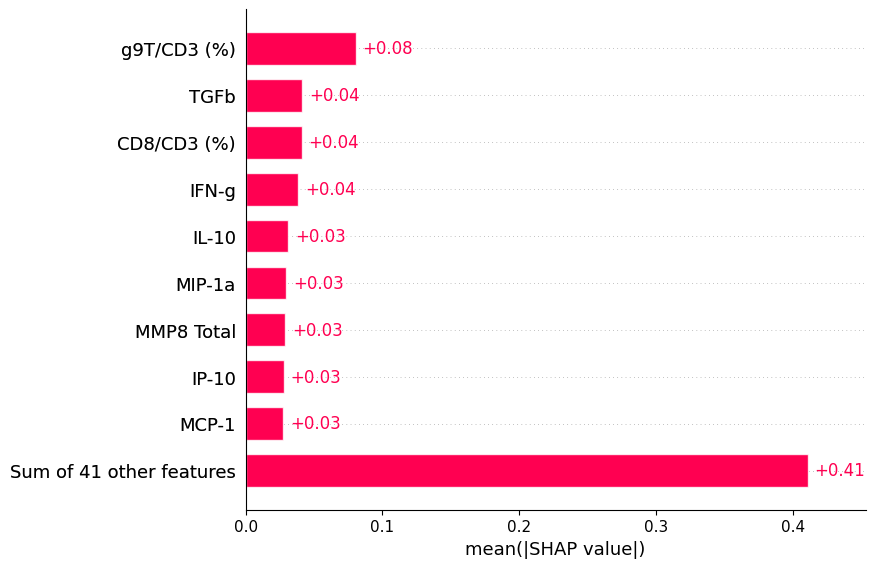

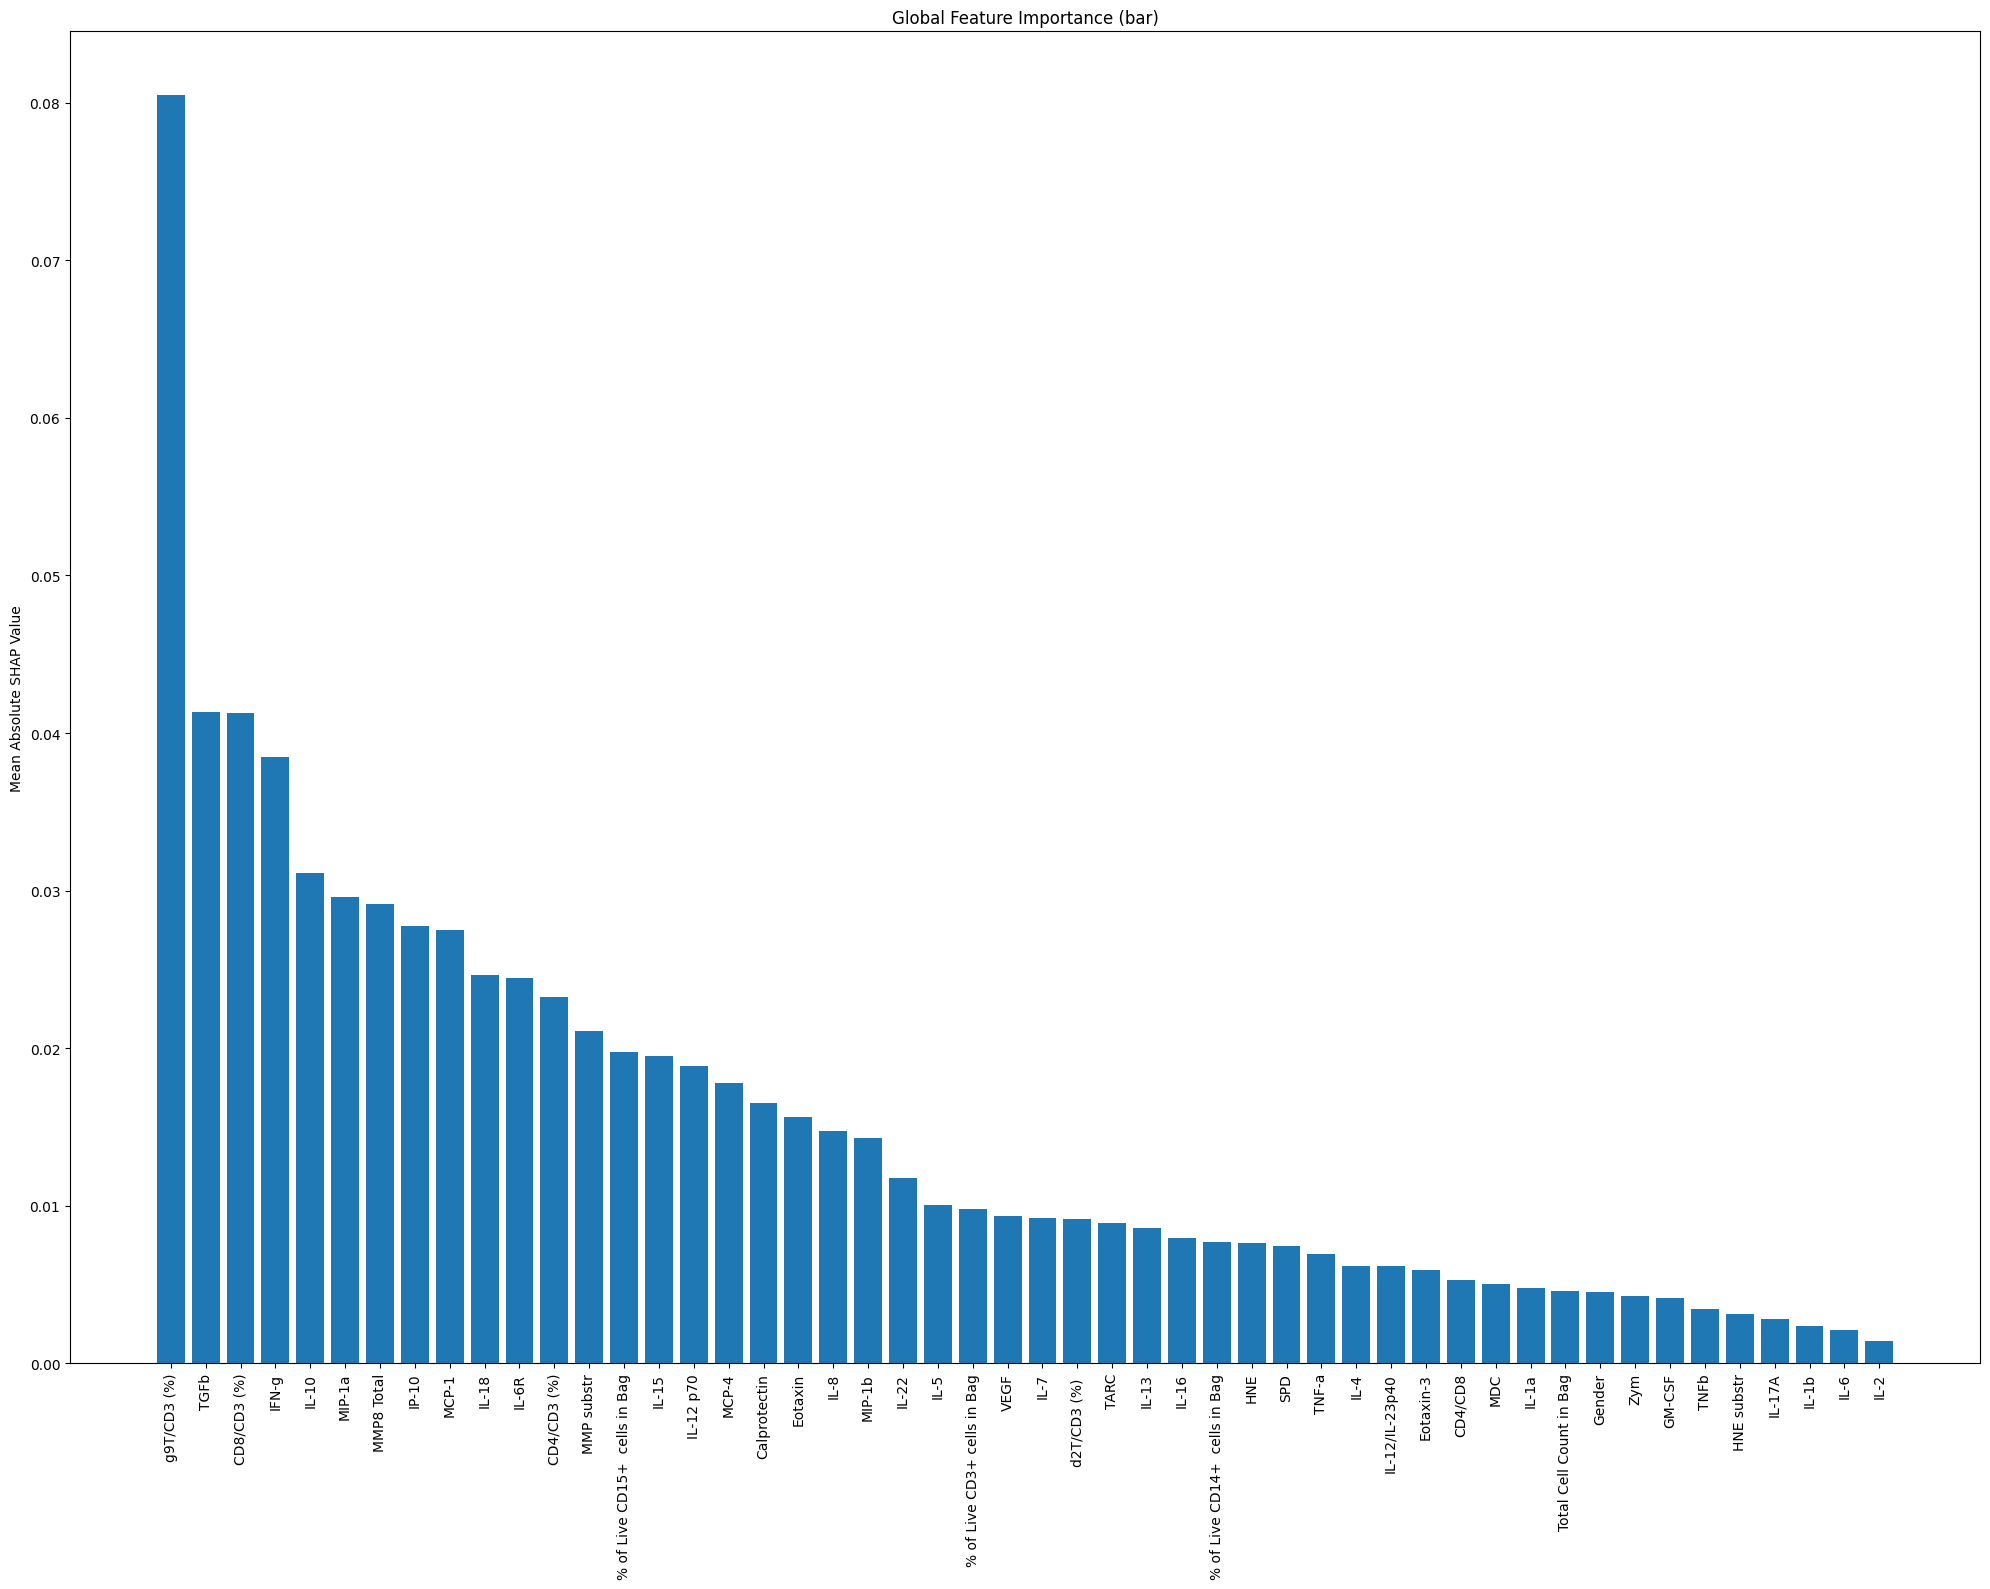

/tmp/ipython-input-2340976278.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


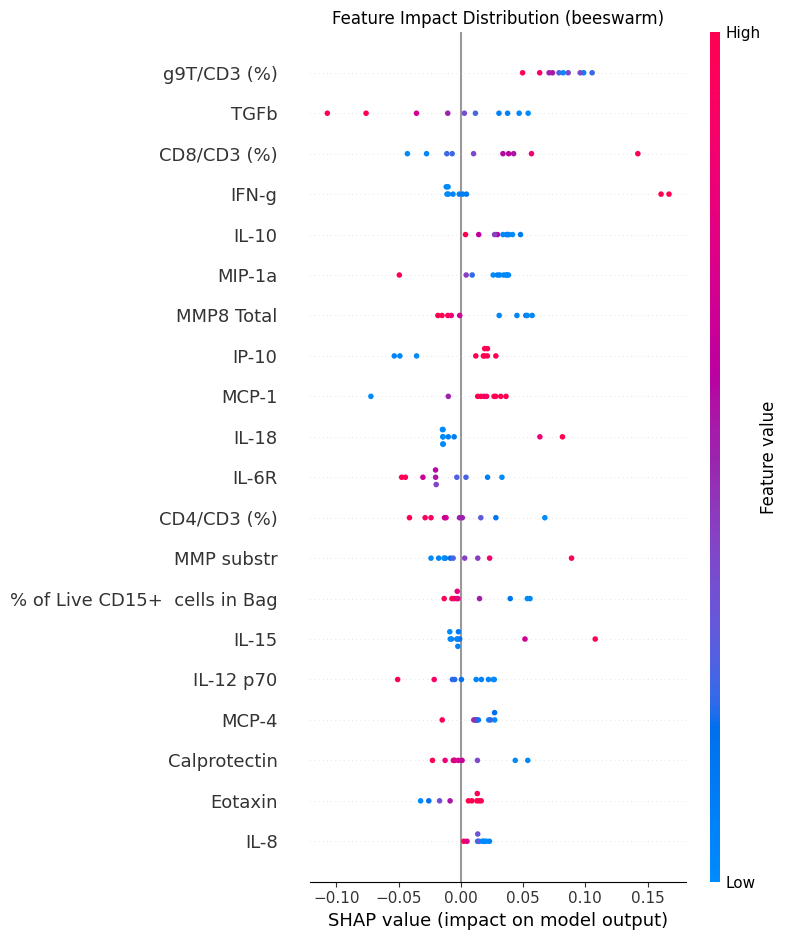


Training fold 2/5
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.5700 - loss: 0.8478 - val_accuracy: 0.7000 - val_loss: 0.7815
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5056 - loss: 0.8226 - val_accuracy: 0.7000 - val_loss: 0.7774
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6136 - loss: 0.7923 - val_accuracy: 0.7000 - val_loss: 0.7781
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6122 - loss: 0.8042 - val_accuracy: 0.7000 - val_loss: 0.7778
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5656 - loss: 0.7787 - val_accuracy: 0.7000 - val_loss: 0.7804
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6337 - loss: 0.6884 - val_accuracy: 0.7000 - val_loss: 0.7824
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7113 - loss: 0.6767 - val_accuracy: 0.8000 - val_loss: 0.7830
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6052 - loss: 0.7298 - val_accuracy:

PermutationExplainer explainer:  50%|█████     | 5/10 [00:00<?, ?it/s]

152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
152/152 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer:  70%|███████   | 7/10 [00:12<00:02,  1.15it/s]

156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


...

PermutationExplainer explainer:  90%|█████████ | 9/10 [00:16<00:01,  1.41s/it]

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 100%|██████████| 10/10 [00:18<00:00,  1.60s/it]

155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 11it [00:20,  3.48s/it]


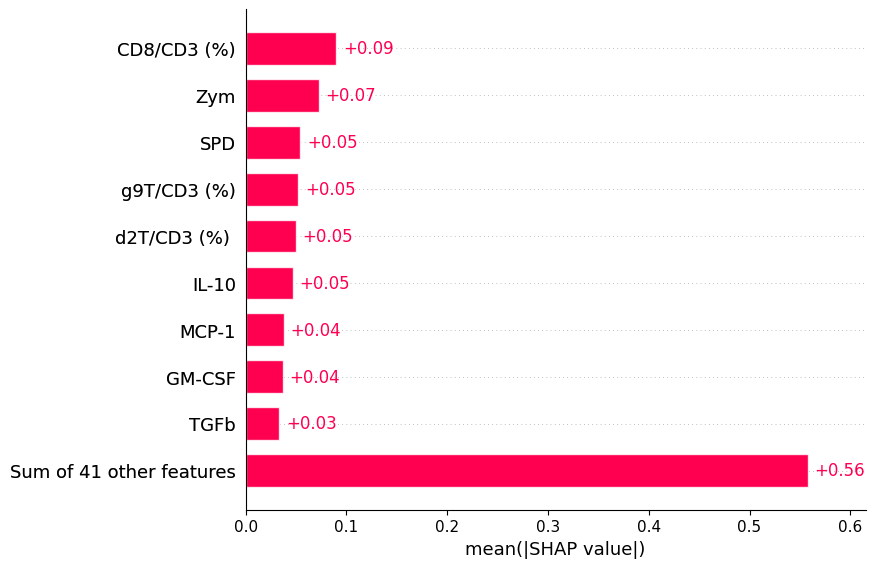

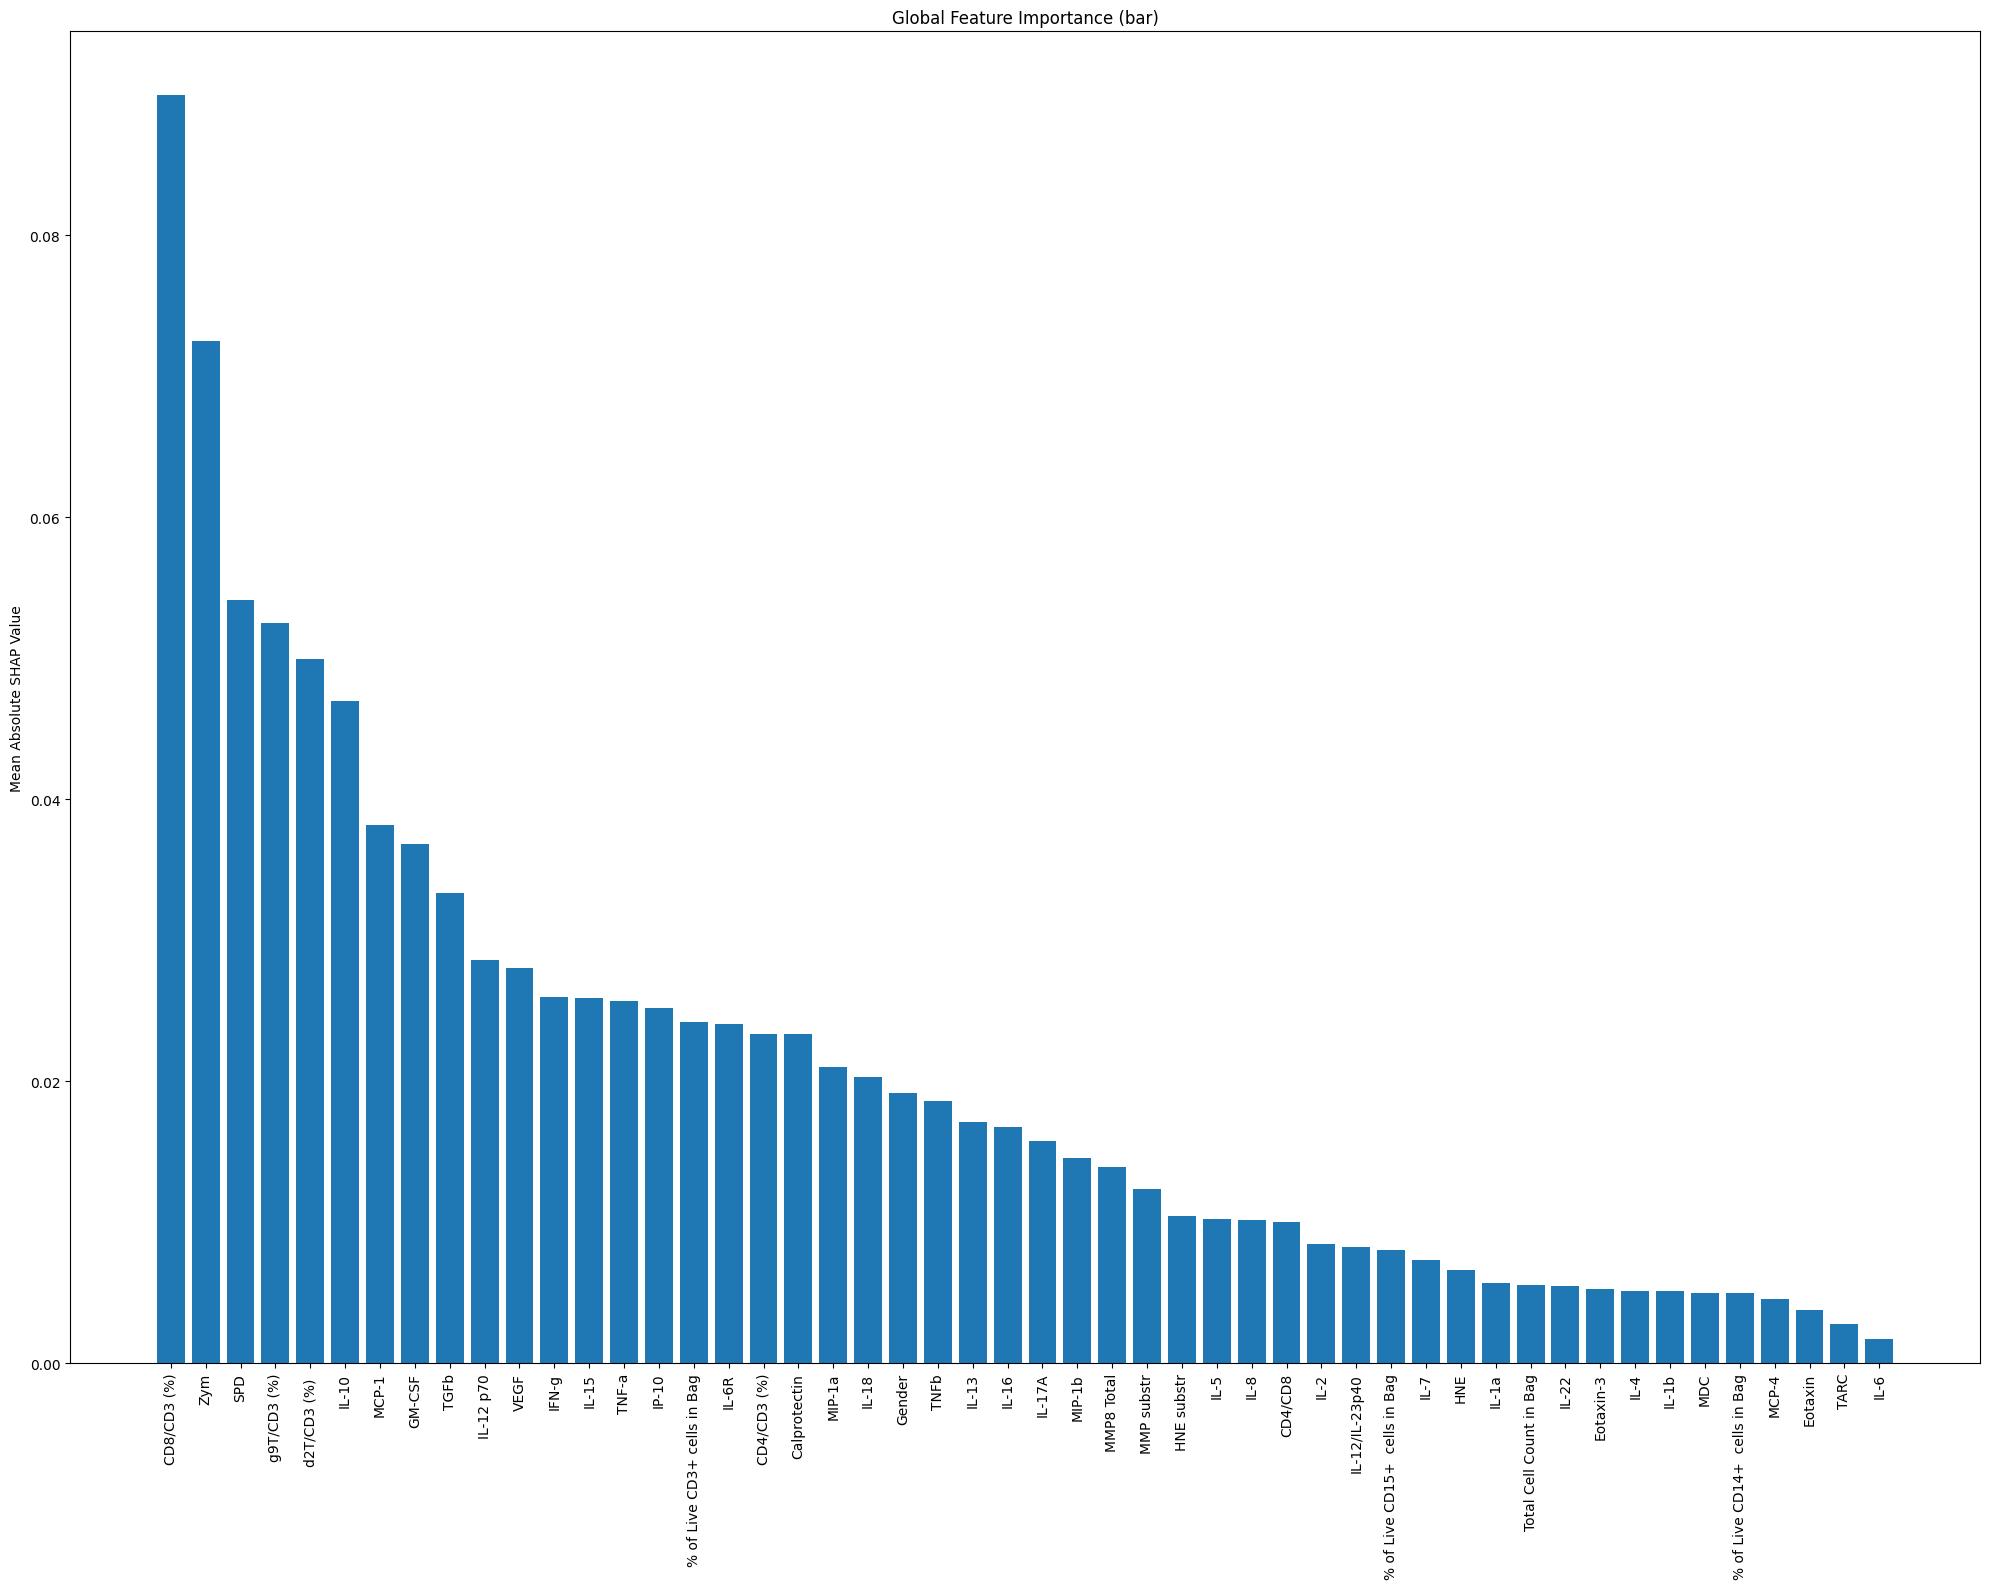

/tmp/ipython-input-2340976278.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


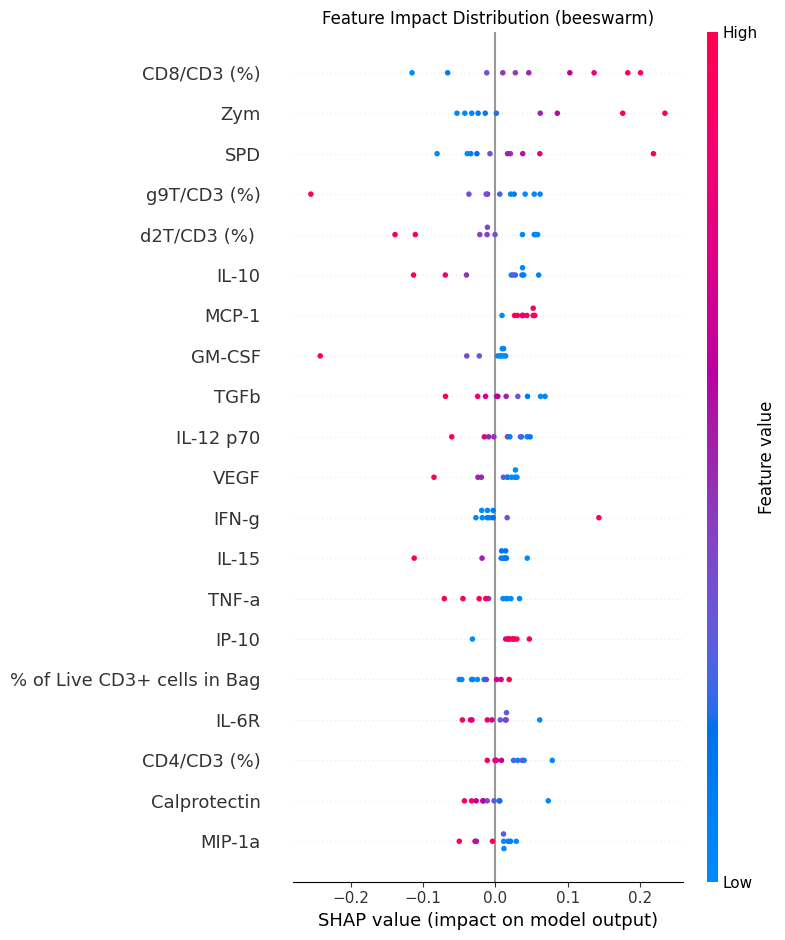


Training fold 3/5
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.5113 - loss: 0.9454 - val_accuracy: 0.5000 - val_loss: 0.8207
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5604 - loss: 0.8371 - val_accuracy: 0.5000 - val_loss: 0.8008
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4792 - loss: 0.8932 - val_accuracy: 0.5000 - val_loss: 0.7819
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5954 - loss: 0.8153 - val_accuracy: 0.5000 - val_loss: 0.7632
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5400 - loss: 0.8491 - val_accuracy: 0.5000 - val_loss: 0.7472
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6837 - loss: 0.7471 - val_accuracy: 0.5000 - val_loss: 0.7334
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7333 - loss: 0.6740 - val_accuracy: 0.6000 - val_loss: 0.7212
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6121 - loss: 0.7421 - val_accuracy

PermutationExplainer explainer:  50%|█████     | 5/10 [00:00<?, ?it/s]

159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer:  70%|███████   | 7/10 [00:12<00:02,  1.06it/s]

168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


...

PermutationExplainer explainer:  90%|█████████ | 9/10 [00:17<00:01,  1.91s/it]

166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 100%|██████████| 10/10 [00:19<00:00,  2.04s/it]

164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
164/164 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 11it [00:21,  3.62s/it]


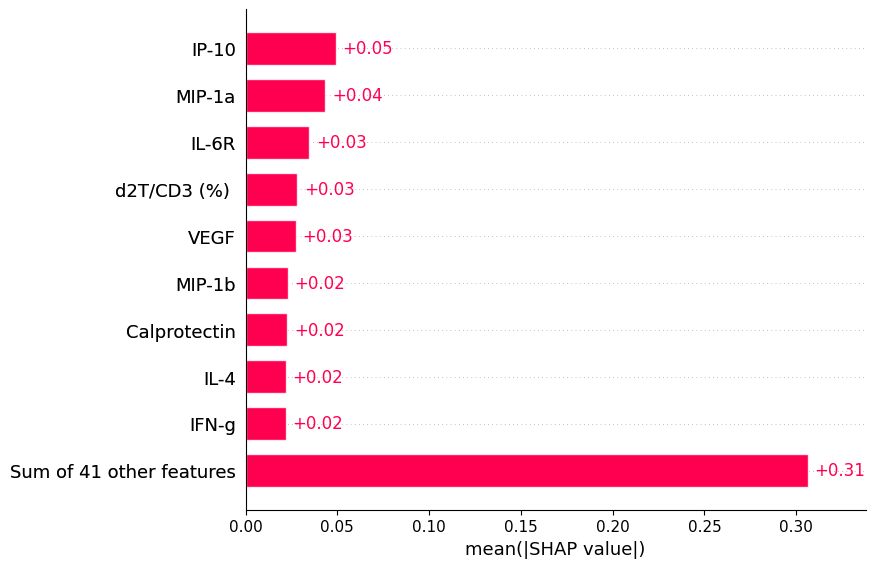

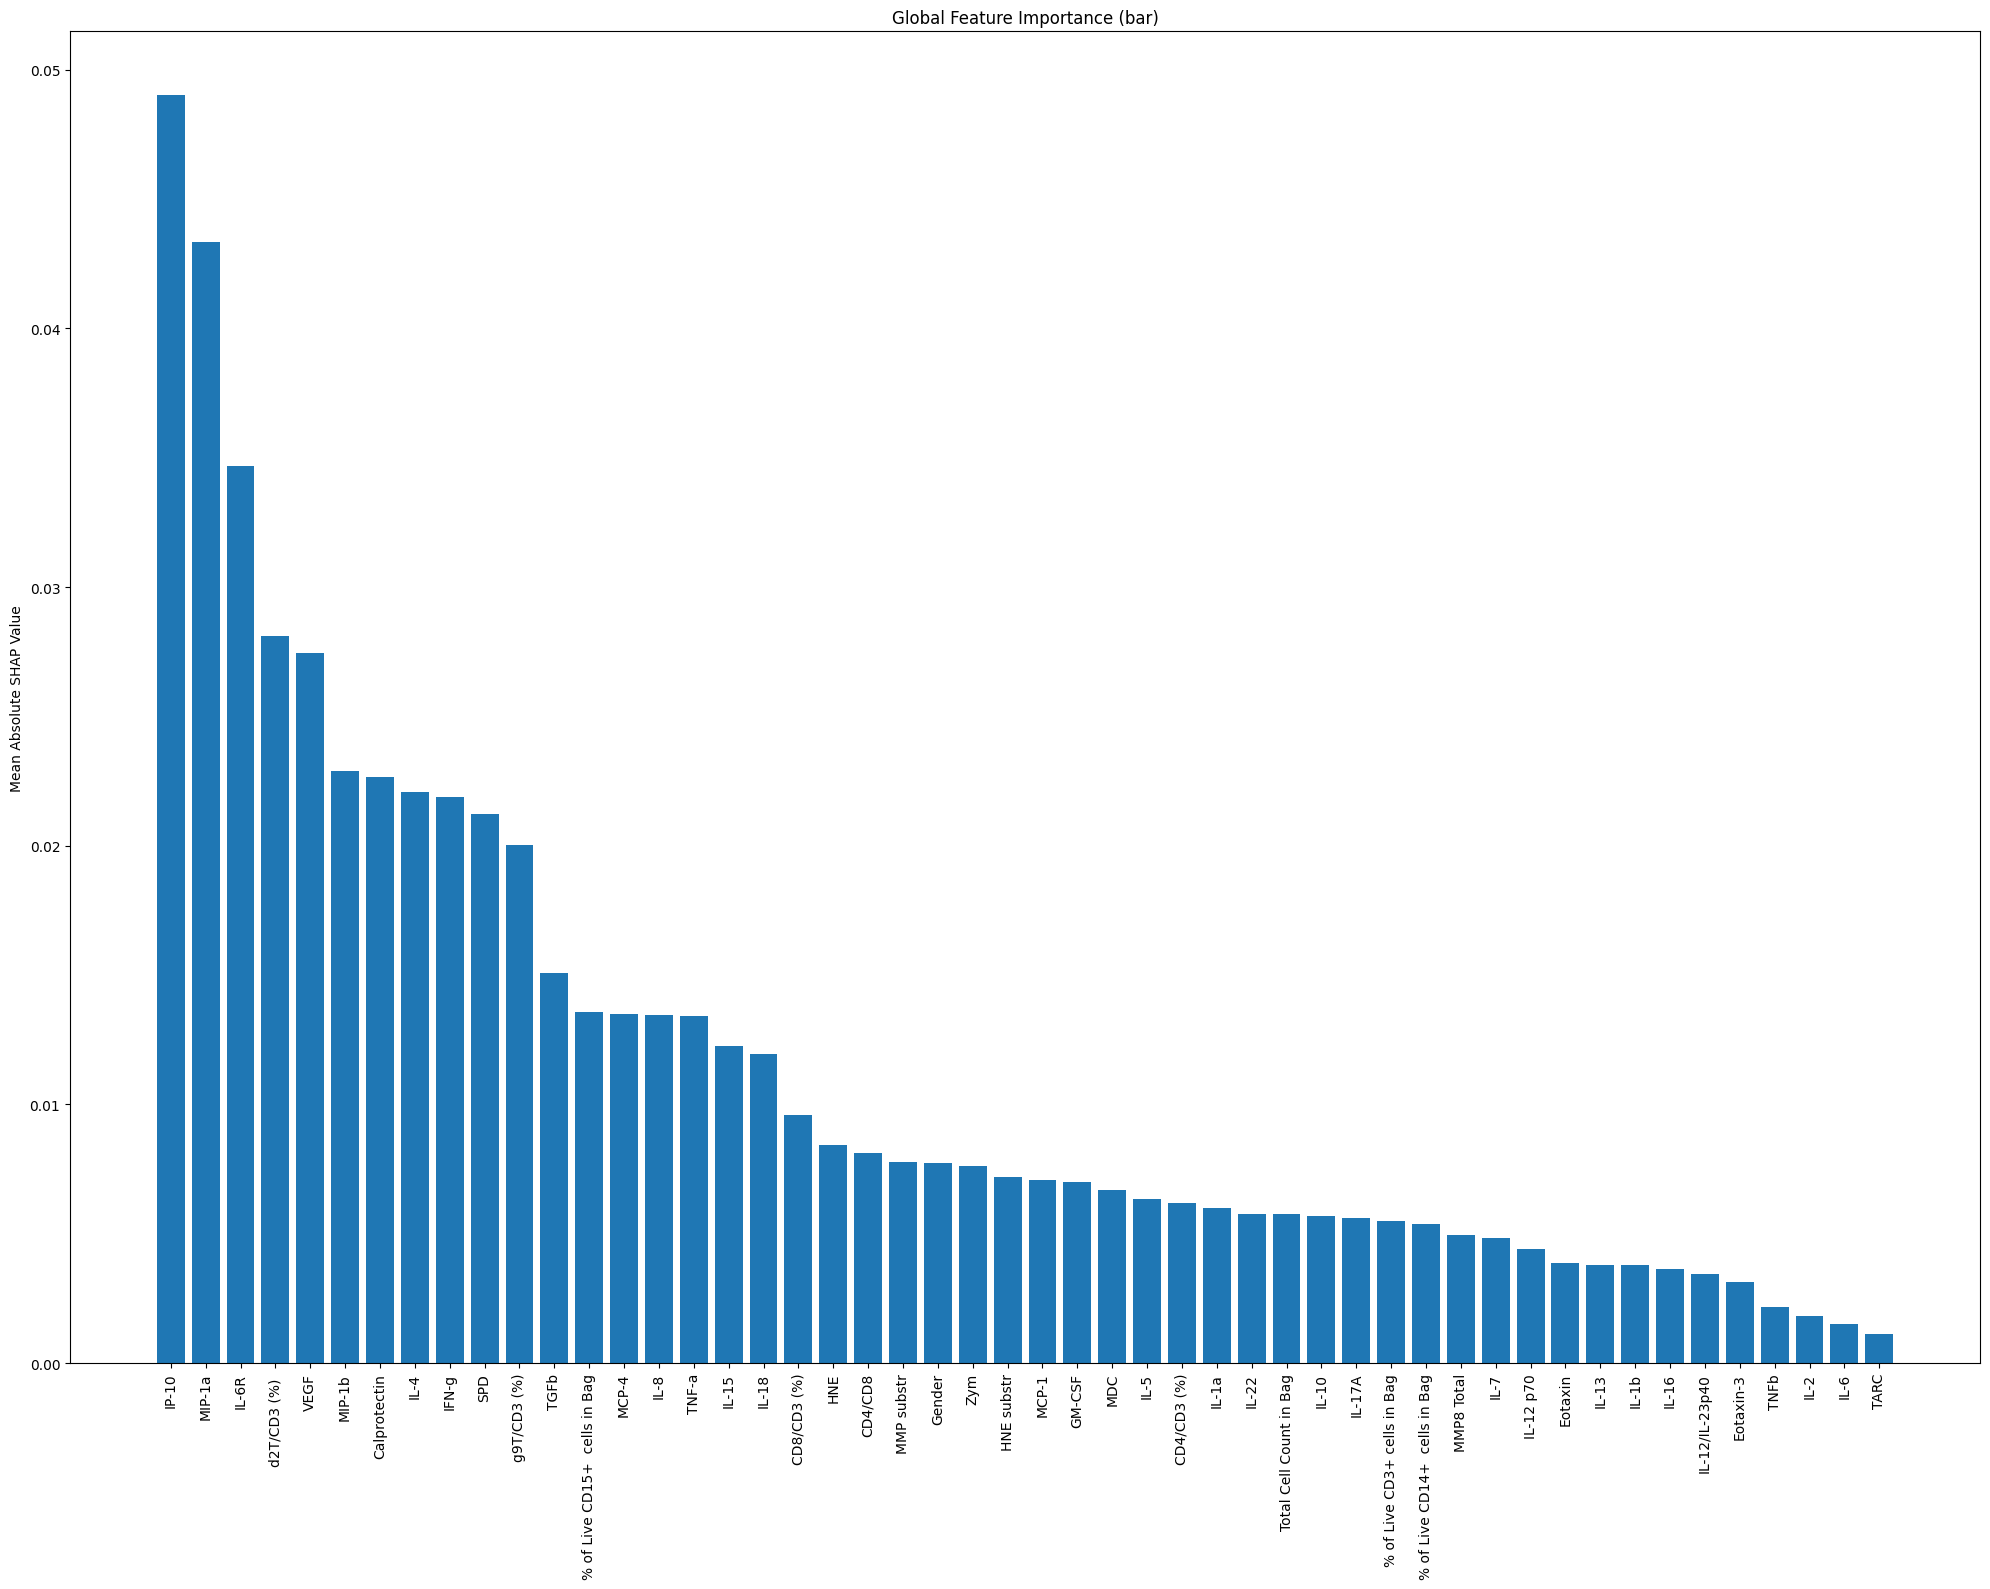

/tmp/ipython-input-2340976278.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


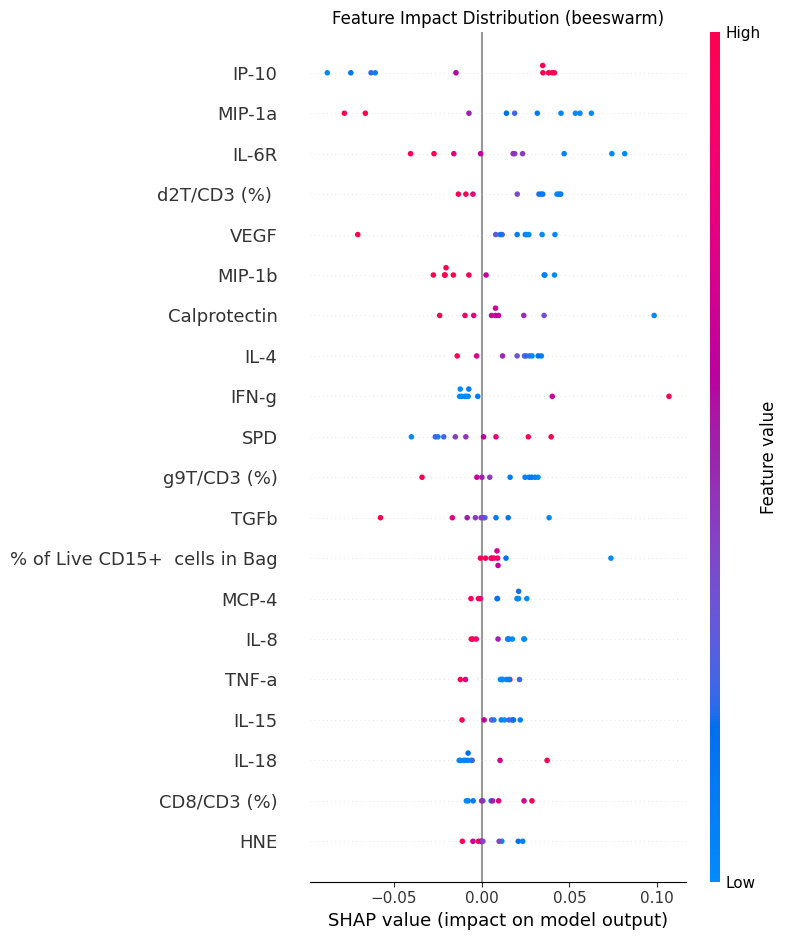


Training fold 4/5
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.5279 - loss: 0.9956 - val_accuracy: 0.2000 - val_loss: 1.0342
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5258 - loss: 0.8917 - val_accuracy: 0.2000 - val_loss: 1.0080
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4258 - loss: 1.0894 - val_accuracy: 0.2000 - val_loss: 0.9847
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4896 - loss: 0.9034 - val_accuracy: 0.2000 - val_loss: 0.9609
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.4396 - loss: 0.9359 - val_accuracy: 0.2000 - val_loss: 0.9390
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.6325 - loss: 0.7953 - val_accuracy: 0.2000 - val_loss: 0.9199
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5275 - loss: 0.8238 - val_accuracy: 0.2000 - val_loss: 0.9042
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5092 - loss: 0.7996 - val_accuracy

PermutationExplainer explainer:  50%|█████     | 5/10 [00:00<?, ?it/s]

168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer:  70%|███████   | 7/10 [00:13<00:03,  1.03s/it]

168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
168/168 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


...

PermutationExplainer explainer:  90%|█████████ | 9/10 [00:16<00:01,  1.61s/it]

167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
167/167 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 100%|██████████| 10/10 [00:18<00:00,  1.73s/it]

174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer: 11it [00:20,  3.48s/it]


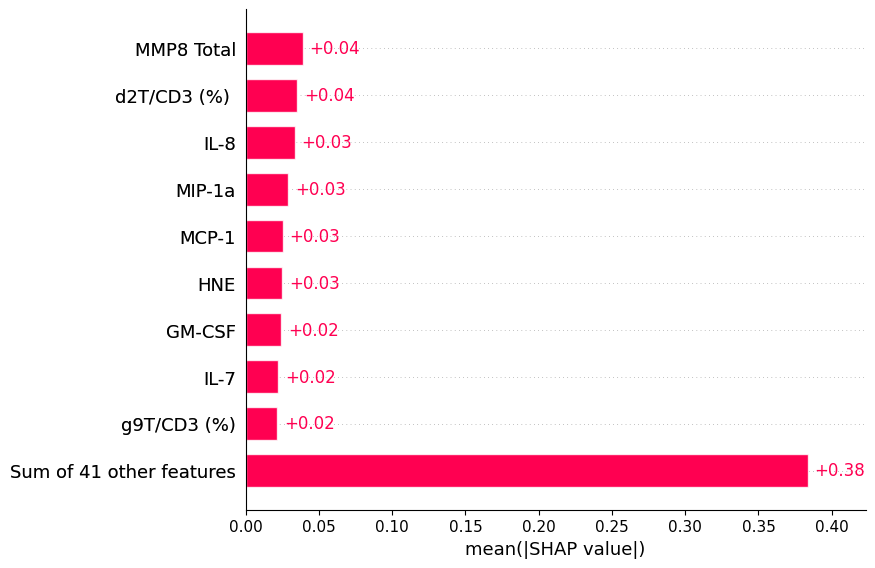

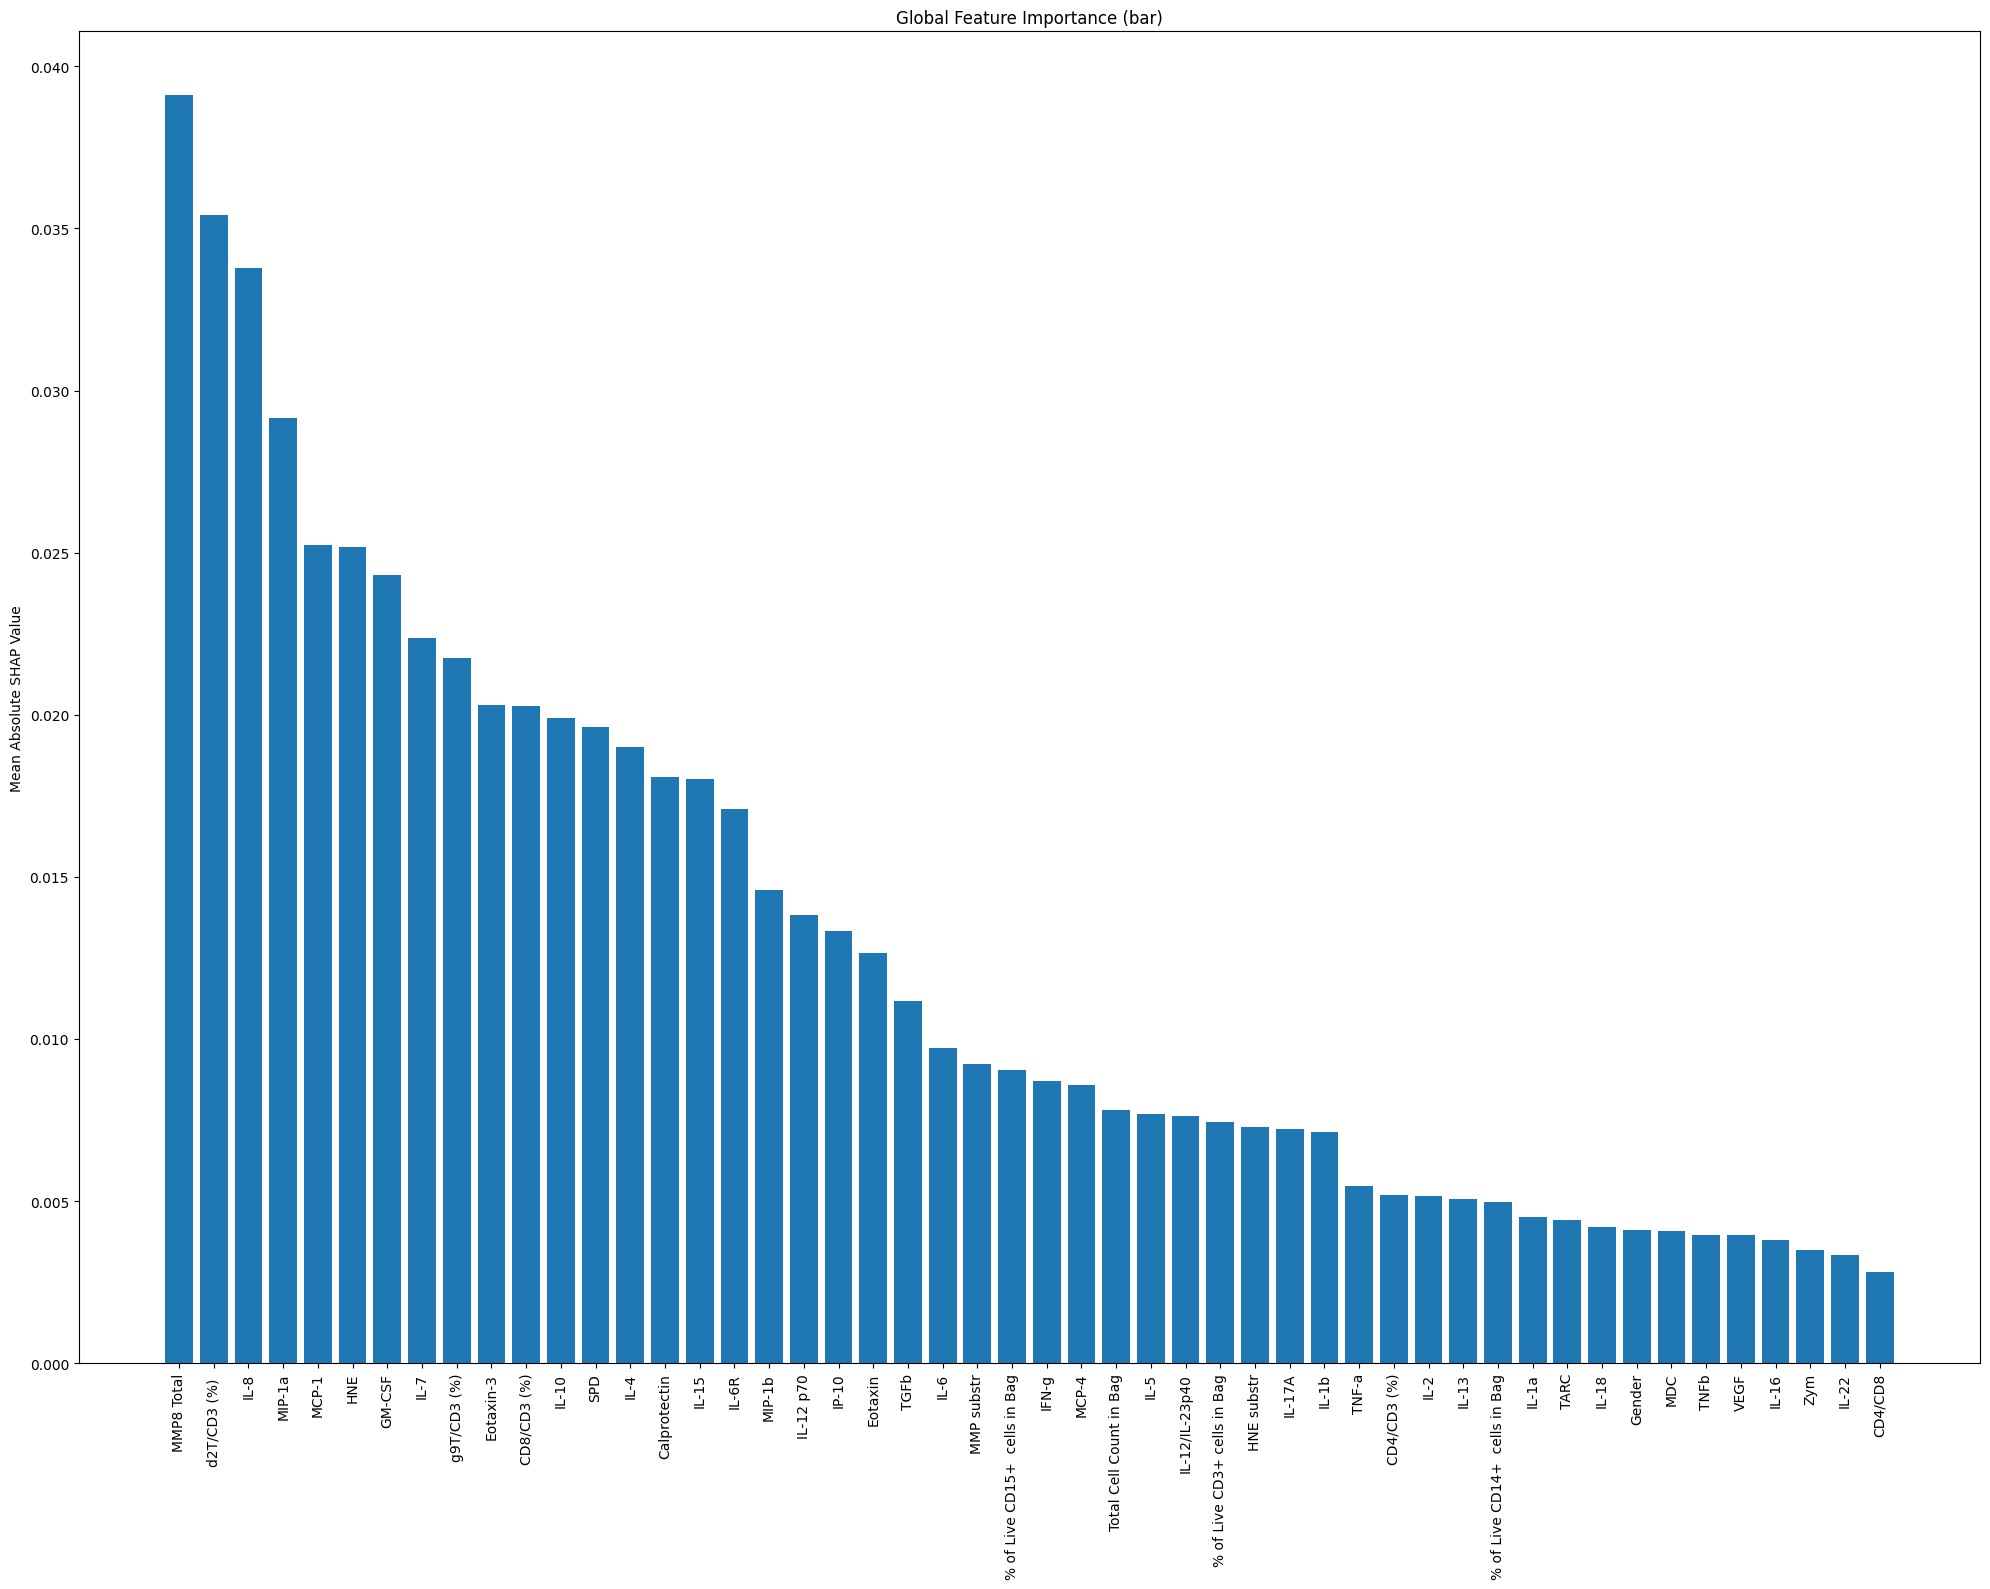

/tmp/ipython-input-2340976278.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


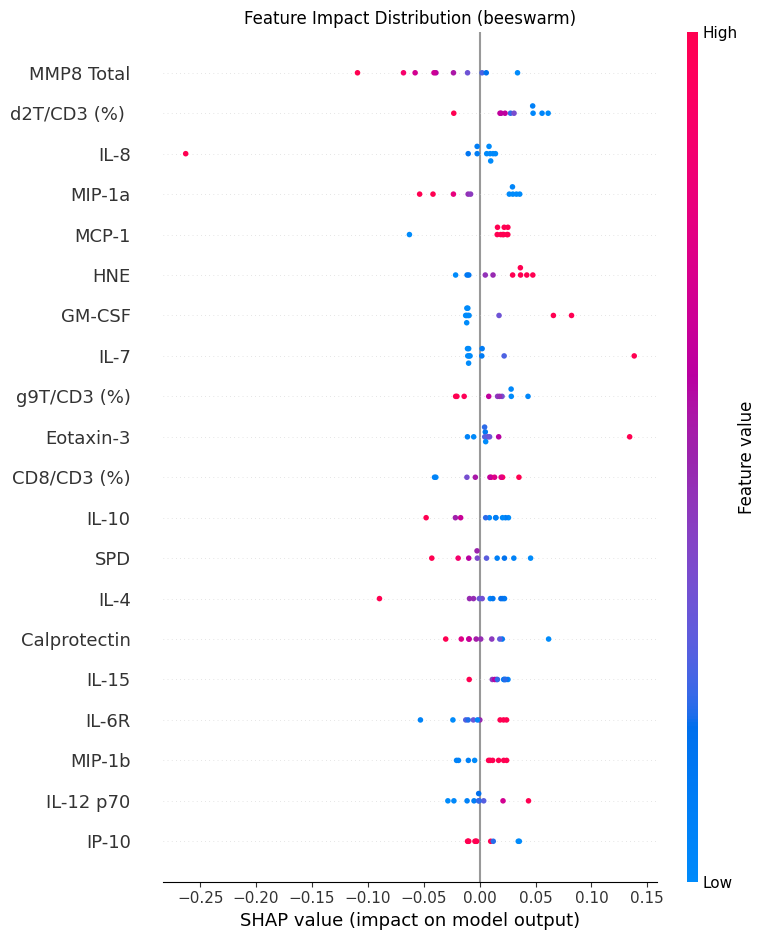


Training fold 5/5
Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - accuracy: 0.4942 - loss: 0.9388 - val_accuracy: 0.5000 - val_loss: 0.7436
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6204 - loss: 0.8653 - val_accuracy: 0.5000 - val_loss: 0.7293
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6146 - loss: 0.8074 - val_accuracy: 0.4000 - val_loss: 0.7199
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6308 - loss: 0.7536 - val_accuracy: 0.5000 - val_loss: 0.7119
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6233 - loss: 0.7649 - val_accuracy: 0.5000 - val_loss: 0.7050
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5671 - loss: 0.7751 - val_accuracy: 0.6000 - val_loss: 0.6990
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6154 - loss: 0.7340 - val_accuracy: 0.6000 - val_loss: 0.6942
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6996 - loss: 0.6857 - val_accuracy

PermutationExplainer explainer:  50%|█████     | 5/10 [00:00<?, ?it/s]

174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer:  70%|███████   | 7/10 [00:13<00:03,  1.07s/it]

169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
169/169 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


...

PermutationExplainer explainer:  90%|█████████ | 9/10 [00:17<00:01,  1.86s/it]

166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 100%|██████████| 10/10 [00:20<00:00,  2.10s/it]

170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 11it [00:22,  3.75s/it]


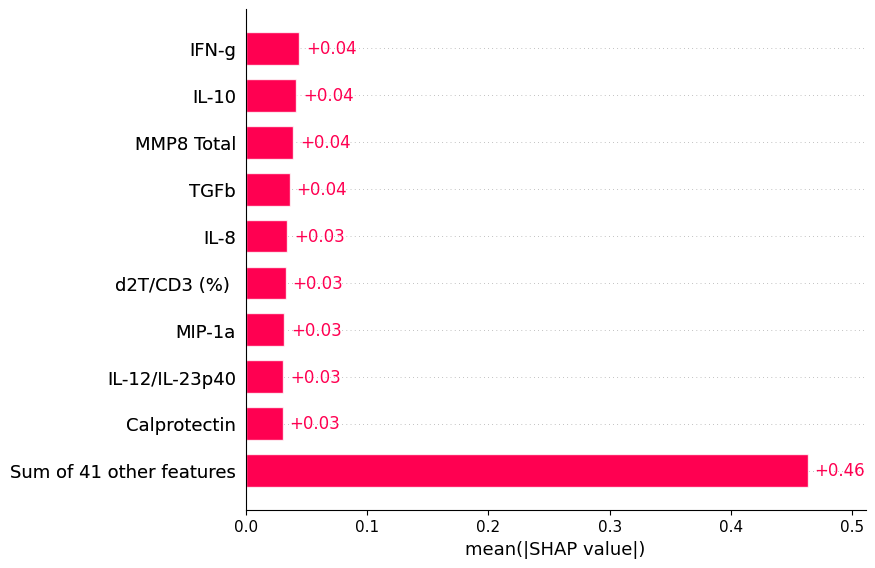

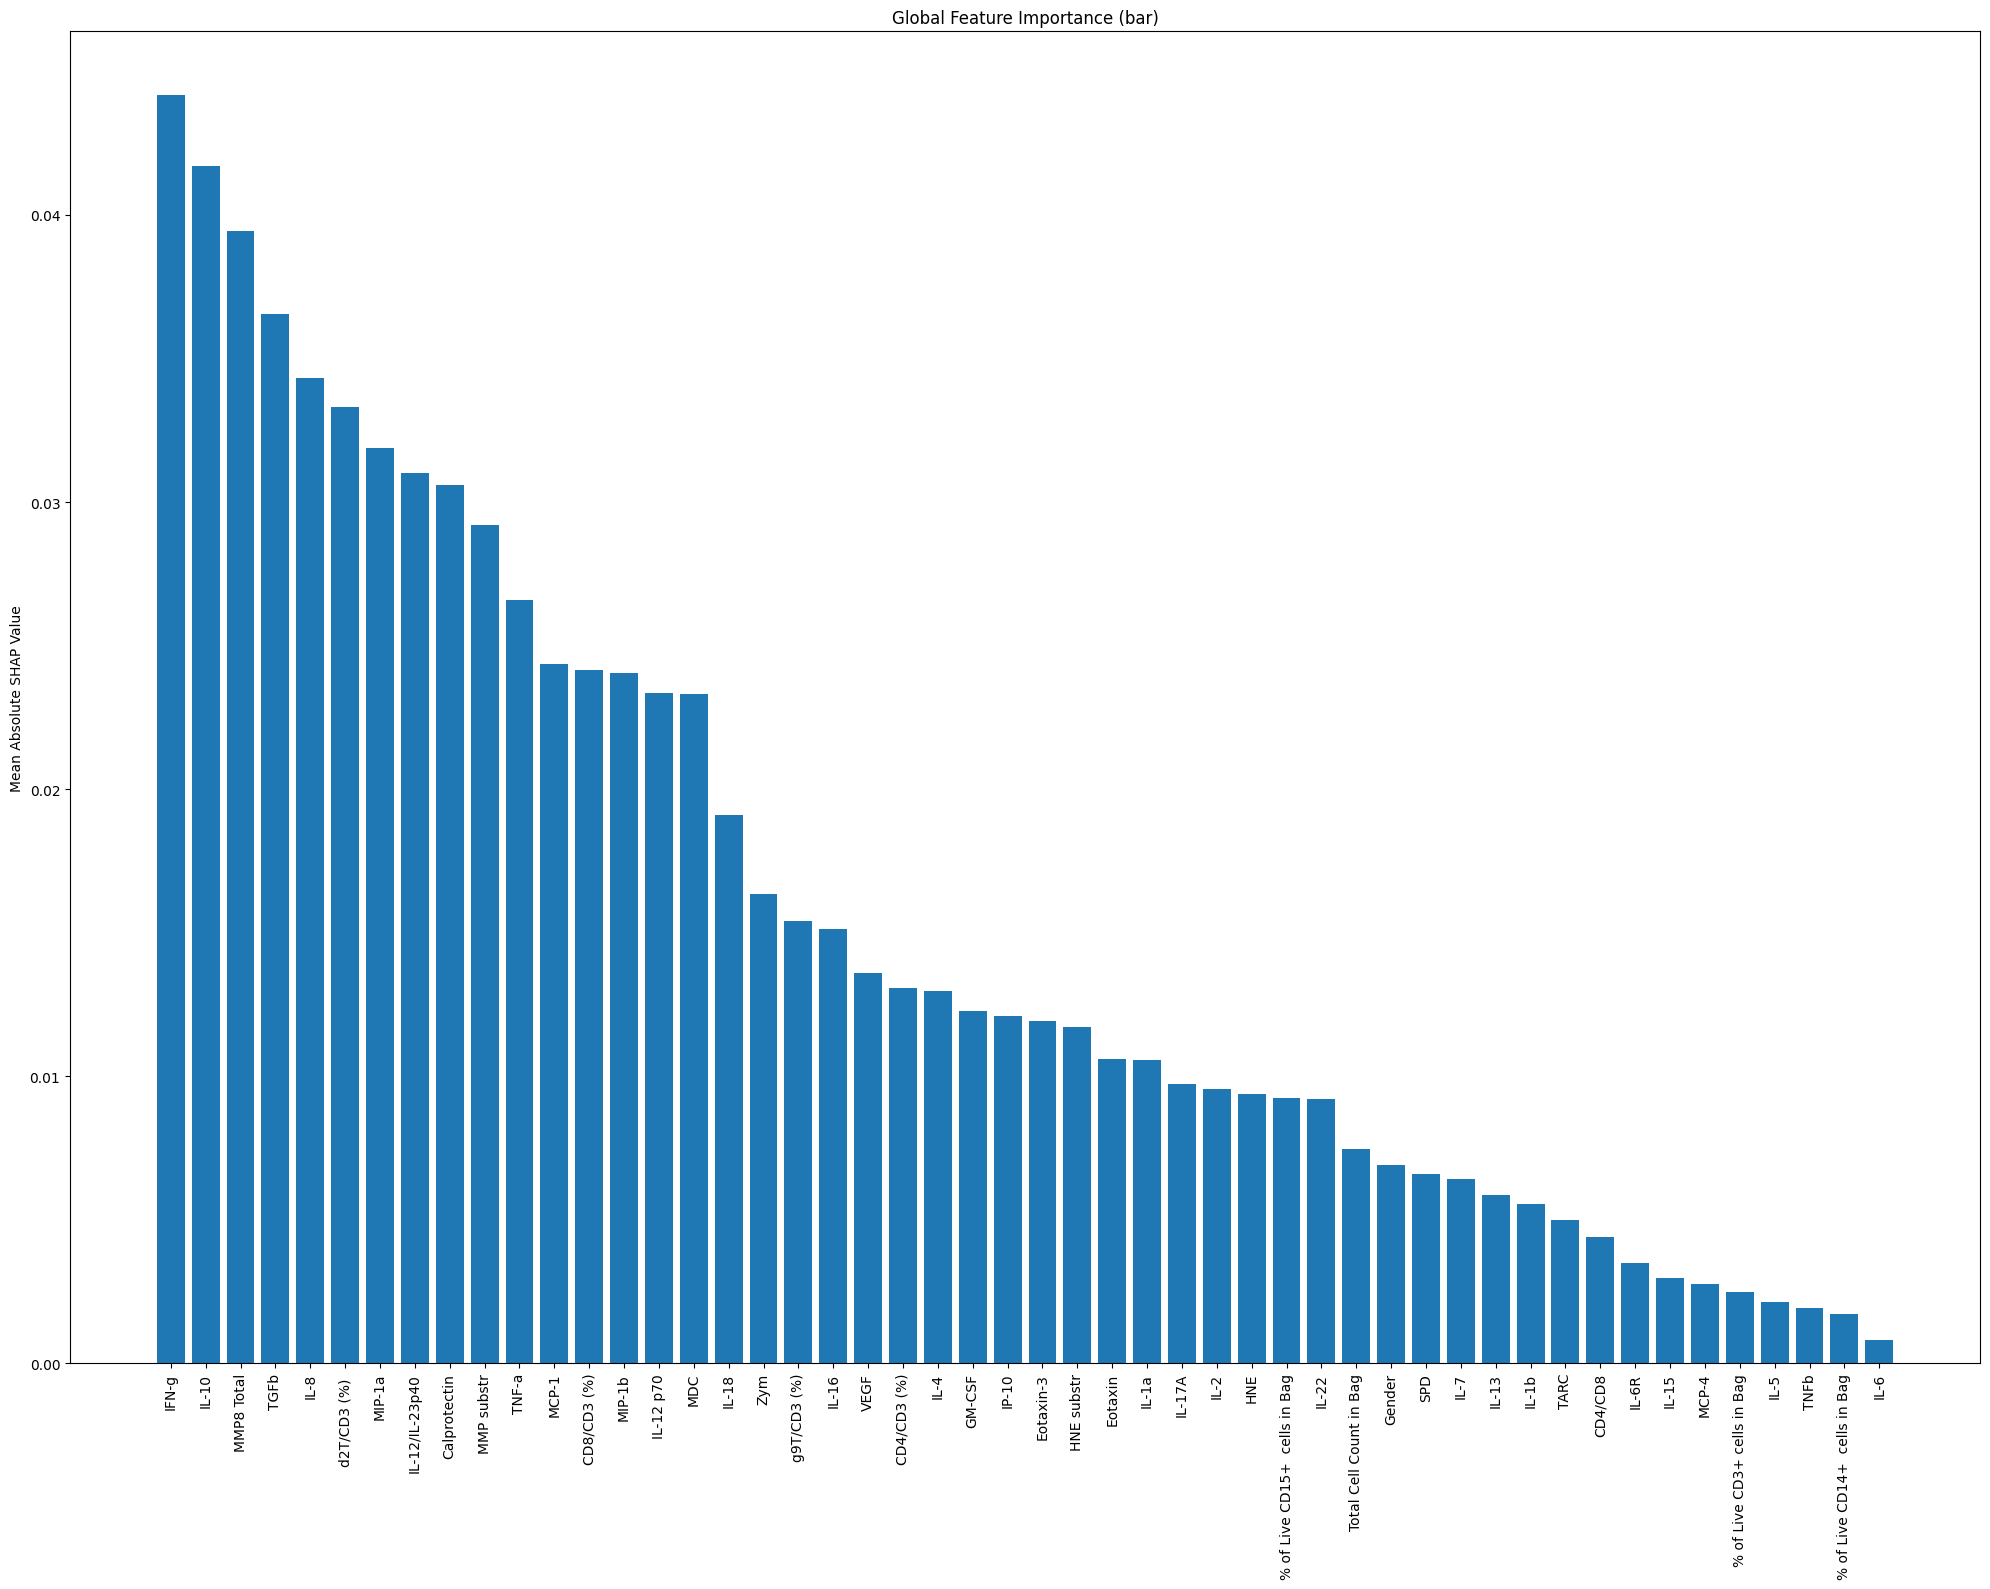

/tmp/ipython-input-2340976278.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


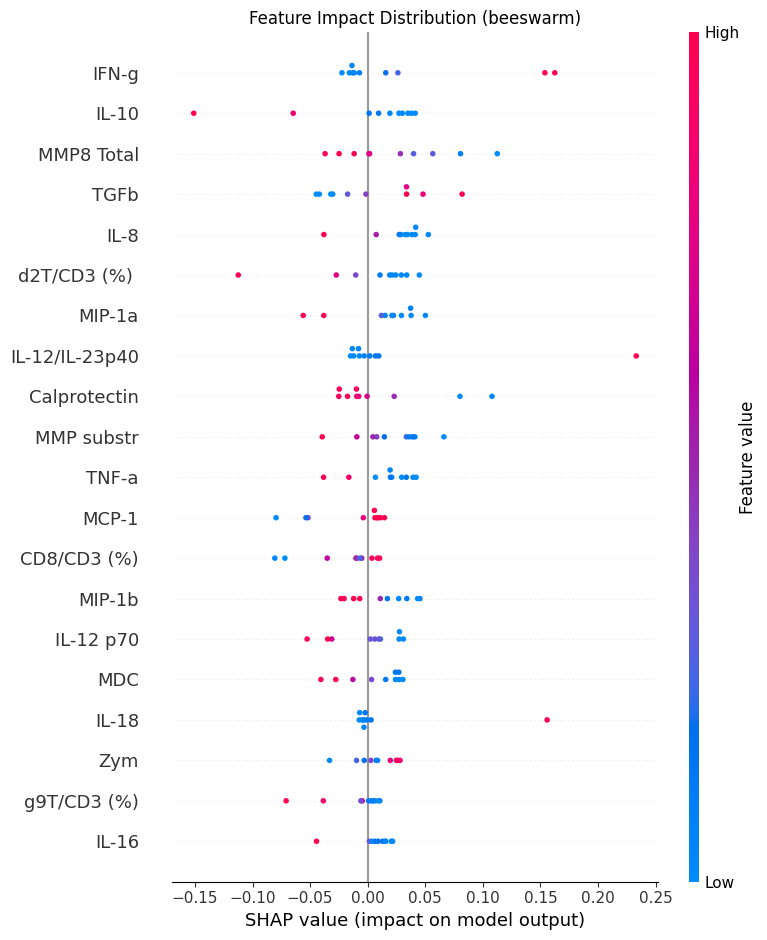

In [ ]:
k_folds = 5
outer_cv = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Storage for fold-level outputs
results = []
all_predictions = []
all_shap = []
all_rankings = []
perm_importance_all_folds = []

fold_num = 1
for train_idx, val_idx in outer_cv.split(X_train, Y_train):
    print(f"\nTraining fold {fold_num}/{k_folds}")

    # --- Split data into training and validation partitions ---
    x_train_fold = X_train.iloc[train_idx]
    y_train_fold = Y_train.iloc[train_idx]
    ids_train_fold = ids_train.iloc[train_idx]

    x_val_fold = X_train.iloc[val_idx]
    y_val_fold = Y_train.iloc[val_idx]
    ids_val_fold = ids_train.iloc[val_idx]

    # --- Oversample the training fold to address class imbalance ---
    ros = RandomOverSampler(random_state=42)
    train_res_df = save_fold_splits(
        fold_num,
        x_train_fold, y_train_fold,
        x_val_fold, y_val_fold,
        ids_train_fold, ids_val_fold,
        ros=ros
    )

    # Extract resampled features, labels, and IDs
    ids_train_res = train_res_df["patient_id"]
    y_train_res = train_res_df["label"]
    x_train_res = train_res_df.drop(columns=["patient_id", "label"])

    # --- Train fold-specific model ---
    model = train_model(
        x_train_res, y_train_res,
        x_val_fold, y_val_fold,
        fold_num,
        input_dim=X_train.shape[1]
    )

    # --- Evaluate on validation fold ---
    preds_df, metrics = evaluate_model(
        model, x_val_fold, y_val_fold,
        fold_num, ids=ids_val_fold
    )
    all_predictions.append(preds_df)
    results.append(metrics)

    # --- Compute SHAP values for this fold ---
    print(f"training shap for fold {fold_num}")
    shap_df, shap_values, explanation_shap_fold = compute_shap_values(
        model,
        x_train_res,
        x_val_fold,
        feature_names=X_train.columns,
        fold_num=fold_num
    )

    # Global SHAP bar plot
    explanation_copy_bar = copy.deepcopy(explanation_shap_fold)
    shap.plots.bar(explanation_copy_bar)

    # Global ranking (mean |SHAP|)
    ranking_df = plot_shap_bar(shap_values, X_train.columns, fold_num=fold_num)

    # Beeswarm plot
    explanation_copy_bee = copy.deepcopy(explanation_shap_fold)
    plot_shap_beeswarm(explanation_copy_bee, x_val_fold, X_train.columns)

    # Attach patient IDs to SHAP values
    shap_df["patient_id"] = ids_val_fold.values

    # Store fold-level outputs
    all_shap.append(shap_df)
    all_rankings.append(ranking_df)

    # Store mean absolute SHAP values for master table
    shap_means_per_fold = {}
    mean_abs_shap = shap_df.drop(columns=["patient_id"], errors="ignore").abs().mean()
    shap_means_per_fold[fold_num] = mean_abs_shap

    fold_num += 1

# --- Save all fold-level outputs ---
pd.concat(all_predictions).to_csv("all_folds_predictions.csv", index=False)
pd.concat(all_shap).to_csv("shap_values_folds.csv", index=False)
pd.DataFrame(results).to_csv("cv_metrics_sumary.csv", index=False)
pd.concat(all_rankings).to_csv("feature_rankings.csv")

### Print to check

In [ ]:
print(all_predictions)

[  patient_id  fold  true  pred      prob
0      056-3     1     1     1  0.738679
1      039-2     1     1     1  0.825343
2      016-1     1     0     1  0.768154
3      002-1     1     1     1  0.798715
4      181-1     1     1     1  0.881623
5      152-4     1     1     1  0.594348
6      189-1     1     0     1  0.906681
7      023-1     1     1     1  0.790575
8      021-1     1     1     1  0.829330
9      027-1     1     1     1  0.769496,   patient_id  fold  true  pred      prob
0      164-2     2     0     0  0.036355
1      135-4     2     1     1  0.819300
2      045-1     2     1     1  0.890483
3      082-4     2     1     1  0.967303
4      167-1     2     1     1  0.968246
5      023-3     2     1     1  0.782161
6      054-3     2     0     0  0.112347
7      025-1     2     1     1  0.985106
8      184-3     2     1     0  0.082120
9      150-2     2     1     1  0.921138,   patient_id  fold  true  pred      prob
0      126-2     3     1     1  0.675121
1      174-1 

In [ ]:
print(all_shap)

[     Gender     IFN-g     IL-1b      IL-2      IL-4      IL-6     IL-10  \
0 -0.004841  0.167218  0.001337 -0.001491 -0.004585 -0.002570  0.038611   
1  0.005202 -0.006241  0.007521 -0.001604  0.000037 -0.002028  0.047971   
2  0.003882 -0.011677  0.000386  0.001394 -0.009276 -0.001870  0.041541   
3  0.001615 -0.011079  0.000446 -0.000213 -0.006307 -0.001894  0.036803   
4  0.004091 -0.001202 -0.003360 -0.001174  0.018104 -0.002001  0.014406   
5  0.005333 -0.009933  0.003693 -0.002732 -0.000064 -0.001643  0.027149   
6 -0.004380  0.001511 -0.001181 -0.001860  0.011619 -0.002204  0.003815   
7  0.003696 -0.010221  0.002445  0.000090 -0.006853 -0.001978  0.033932   
8  0.004144  0.004545  0.002599 -0.003076 -0.004885 -0.002400  0.029447   
9 -0.007696  0.160862 -0.000658 -0.000372  0.000179 -0.002312  0.037531   

   IL-12 p70     IL-13     TNF-a  ...  % of Live CD3+ cells in Bag  \
0   0.012372  0.004878 -0.004460  ...                     0.016485   
1   0.000521  0.002629  0.004836 

In [ ]:
print(results)

[{'fold': 1, 'accuracy': 0.8, 'f1': 0.8888888888888888, 'auc': np.float64(0.375), 'logloss': 0.588344741953583}, {'fold': 2, 'accuracy': 0.9, 'f1': 0.9333333333333333, 'auc': np.float64(0.9375), 'logloss': 0.3379435001784512}, {'fold': 3, 'accuracy': 0.8, 'f1': 0.875, 'auc': np.float64(0.6190476190476191), 'logloss': 0.5318876537263113}, {'fold': 4, 'accuracy': 0.5, 'f1': 0.6153846153846154, 'auc': np.float64(0.4761904761904762), 'logloss': 0.7300362146224297}, {'fold': 5, 'accuracy': 0.8, 'f1': 0.875, 'auc': np.float64(0.7142857142857143), 'logloss': 0.5209551211803847}]


In [ ]:
print(all_rankings)

[    fold                        feature  mean_abs_shap  rank
0      1                    g9T/CD3 (%)       0.080518     1
1      1                           TGFb       0.041319     2
2      1                    CD8/CD3 (%)       0.041250     3
3      1                          IFN-g       0.038449     4
4      1                          IL-10       0.031120     5
5      1                         MIP-1a       0.029622     6
6      1                     MMP8 Total       0.029121     7
7      1                          IP-10       0.027725     8
8      1                          MCP-1       0.027474     9
9      1                          IL-18       0.024656    10
10     1                          IL-6R       0.024448    11
11     1                    CD4/CD3 (%)       0.023268    12
12     1                     MMP substr       0.021087    13
13     1  % of Live CD15+  cells in Bag       0.019770    14
14     1                          IL-15       0.019496    15
15     1               

In [ ]:
print(perm_importance_all_folds)

[]


# Fold level Stats

In [ ]:
# # Stats at fold level:
## Cannot use KW as the data is fold specific and therefore not a fair measure
# kruskal_fold = compute_kruskal_shap(
#     feature_names = X_train.columns,
#     all_shap = all_shap
# )
# kruskal_fold.to_csv("kruskal_results_fold.csv", index=False)

def compute_feature_rank_stability(all_rankings):
  rank_matrix = pd.concat(all_rankings).pivot(index="feature", columns="fold", values="rank")
  folds = rank_matrix.columns
  corr_matrix = pd.DataFrame(index=folds, columns=folds, dtype=float)

  for i in folds:
    for j in folds:
      corr, _ = spearmanr(rank_matrix[i], rank_matrix[j])
      corr_matrix.loc[i, j] = corr
  return corr_matrix

#### PAIRWISE SPEARMAN CORRELATIONS BETWEEN FOLDS RANKINGS

fold_spear = compute_feature_rank_stability(all_rankings)
print(fold_spear)

# Build a rank matrix
rank_matrix = pd.concat(all_rankings).pivot(index="feature", columns="fold", values="rank")

#### HOW WELL EACH FOLDS RANKING AGREES WITH THE AVERAGE RANKING ACROSS FOLDS

# Fold wise agreement (each fold vs consensus)
consensus = rank_matrix.mean(axis=1) # average rank per feature across folds

fold_agreement = []
for fold in rank_matrix.columns:
  corr, _ = spearmanr(rank_matrix[fold], consensus)
  fold_agreement.append({"fold": fold, "spearman_corr": corr})

fold_agreement_df = pd.DataFrame(fold_agreement)
print(fold_agreement_df)


# Feature wise stability
rank_matrix["rank_mean"] = rank_matrix.mean(axis=1)
rank_matrix["rank_std"] = rank_matrix.std(axis=1)

feature_stability_df = rank_matrix[["rank_mean", "rank_std"]]
# print(feature_stability_df)

ordered_feature_stability_df = feature_stability_df.sort_values("rank_mean", ascending=True)
print(ordered_feature_stability_df)

ordered_feature_stability_df.to_csv("feature_stability.csv", index=True)


fold         1         2         3         4         5
fold                                                  
1     1.000000  0.421945  0.474190  0.432605  0.457095
2     0.421945  1.000000  0.457671  0.251285  0.444802
3     0.474190  0.457671  1.000000  0.320912  0.343962
4     0.432605  0.251285  0.320912  1.000000  0.369988
5     0.457095  0.444802  0.343962  0.369988  1.000000
   fold  spearman_corr
0     1       0.776025
1     2       0.712917
2     3       0.714646
3     4       0.676896
4     5       0.702399
fold                           rank_mean   rank_std
feature                                            
MIP-1a                               7.8   6.337192
d2T/CD3 (%)                          8.8   9.195651
g9T/CD3 (%)                          8.8   6.209670
CD8/CD3 (%)                          9.4   6.621178
TGFb                                 9.8   7.054077
IFN-g                               10.4   8.685620
IL-10                               11.8  11.565466
MCP-1    

# Averaged Ensemble

In [ ]:
def load_fold_models(k_folds):
  models = []
  for fold_num in range(1, k_folds+1):
    model = tf.keras.models.load_model(f"model_{fold_num}.keras")
    models.append(model)
  return models

In [ ]:
def ensemble_predict(models, X):
  # collect predictions from each fold model
  preds = [m.predict(X).flatten() for m in models]
  preds = np.vstack(preds) # shape: n_folds, n_samples
  return preds.mean(axis=0)

In [ ]:
class EnsembleWrapper:
  def __init__(self, models):
    self.models = models
  def predict(self, X):
    # average predictions across models

    preds = [m.predict(X).flatten() for m in self.models]
    avg_preds = np.mean(preds, axis=0)
    # LIME expects probabilities for both classes: [1-p, p]
    return np.vstack([1 - avg_preds, avg_preds]).T

# class EnsembleWrapper:
#   def __init__(self, models):
#     self.models = models
#   def predict(self, X):
#     # average predictions across models

#     preds = [m.predict(X).flatten() for m in self.models]
#     return np.mean(preds, axis=0).reshape(-1, 1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
{'fold': 'ensemble', 'accuracy': 0.6153846153846154, 'f1': 0.7368421052631579, 'auc': np.float64(0.5833333333333333), 'logloss': 0.6576582494184877}
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2m

PermutationExplainer explainer:  15%|█▌        | 2/13 [00:00<?, ?it/s]

137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
80/80 ━━━━━━━━━━━━━━━━━━

...

PermutationExplainer explainer:  92%|█████████▏| 12/13 [01:33<00:08,  8.67s/it]

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
77/77 ━━━━━━━━━━━━━━━━━━

PermutationExplainer explainer: 100%|██████████| 13/13 [01:40<00:00,  8.40s/it]

145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
80/80 ━━━━━━━━━━━━━━━━━━

PermutationExplainer explainer: 14it [01:50,  9.23s/it]


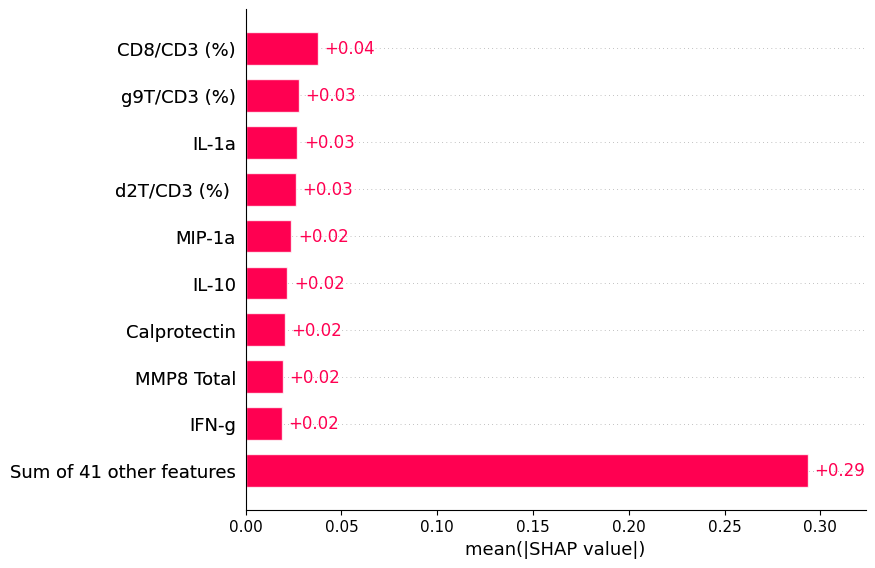

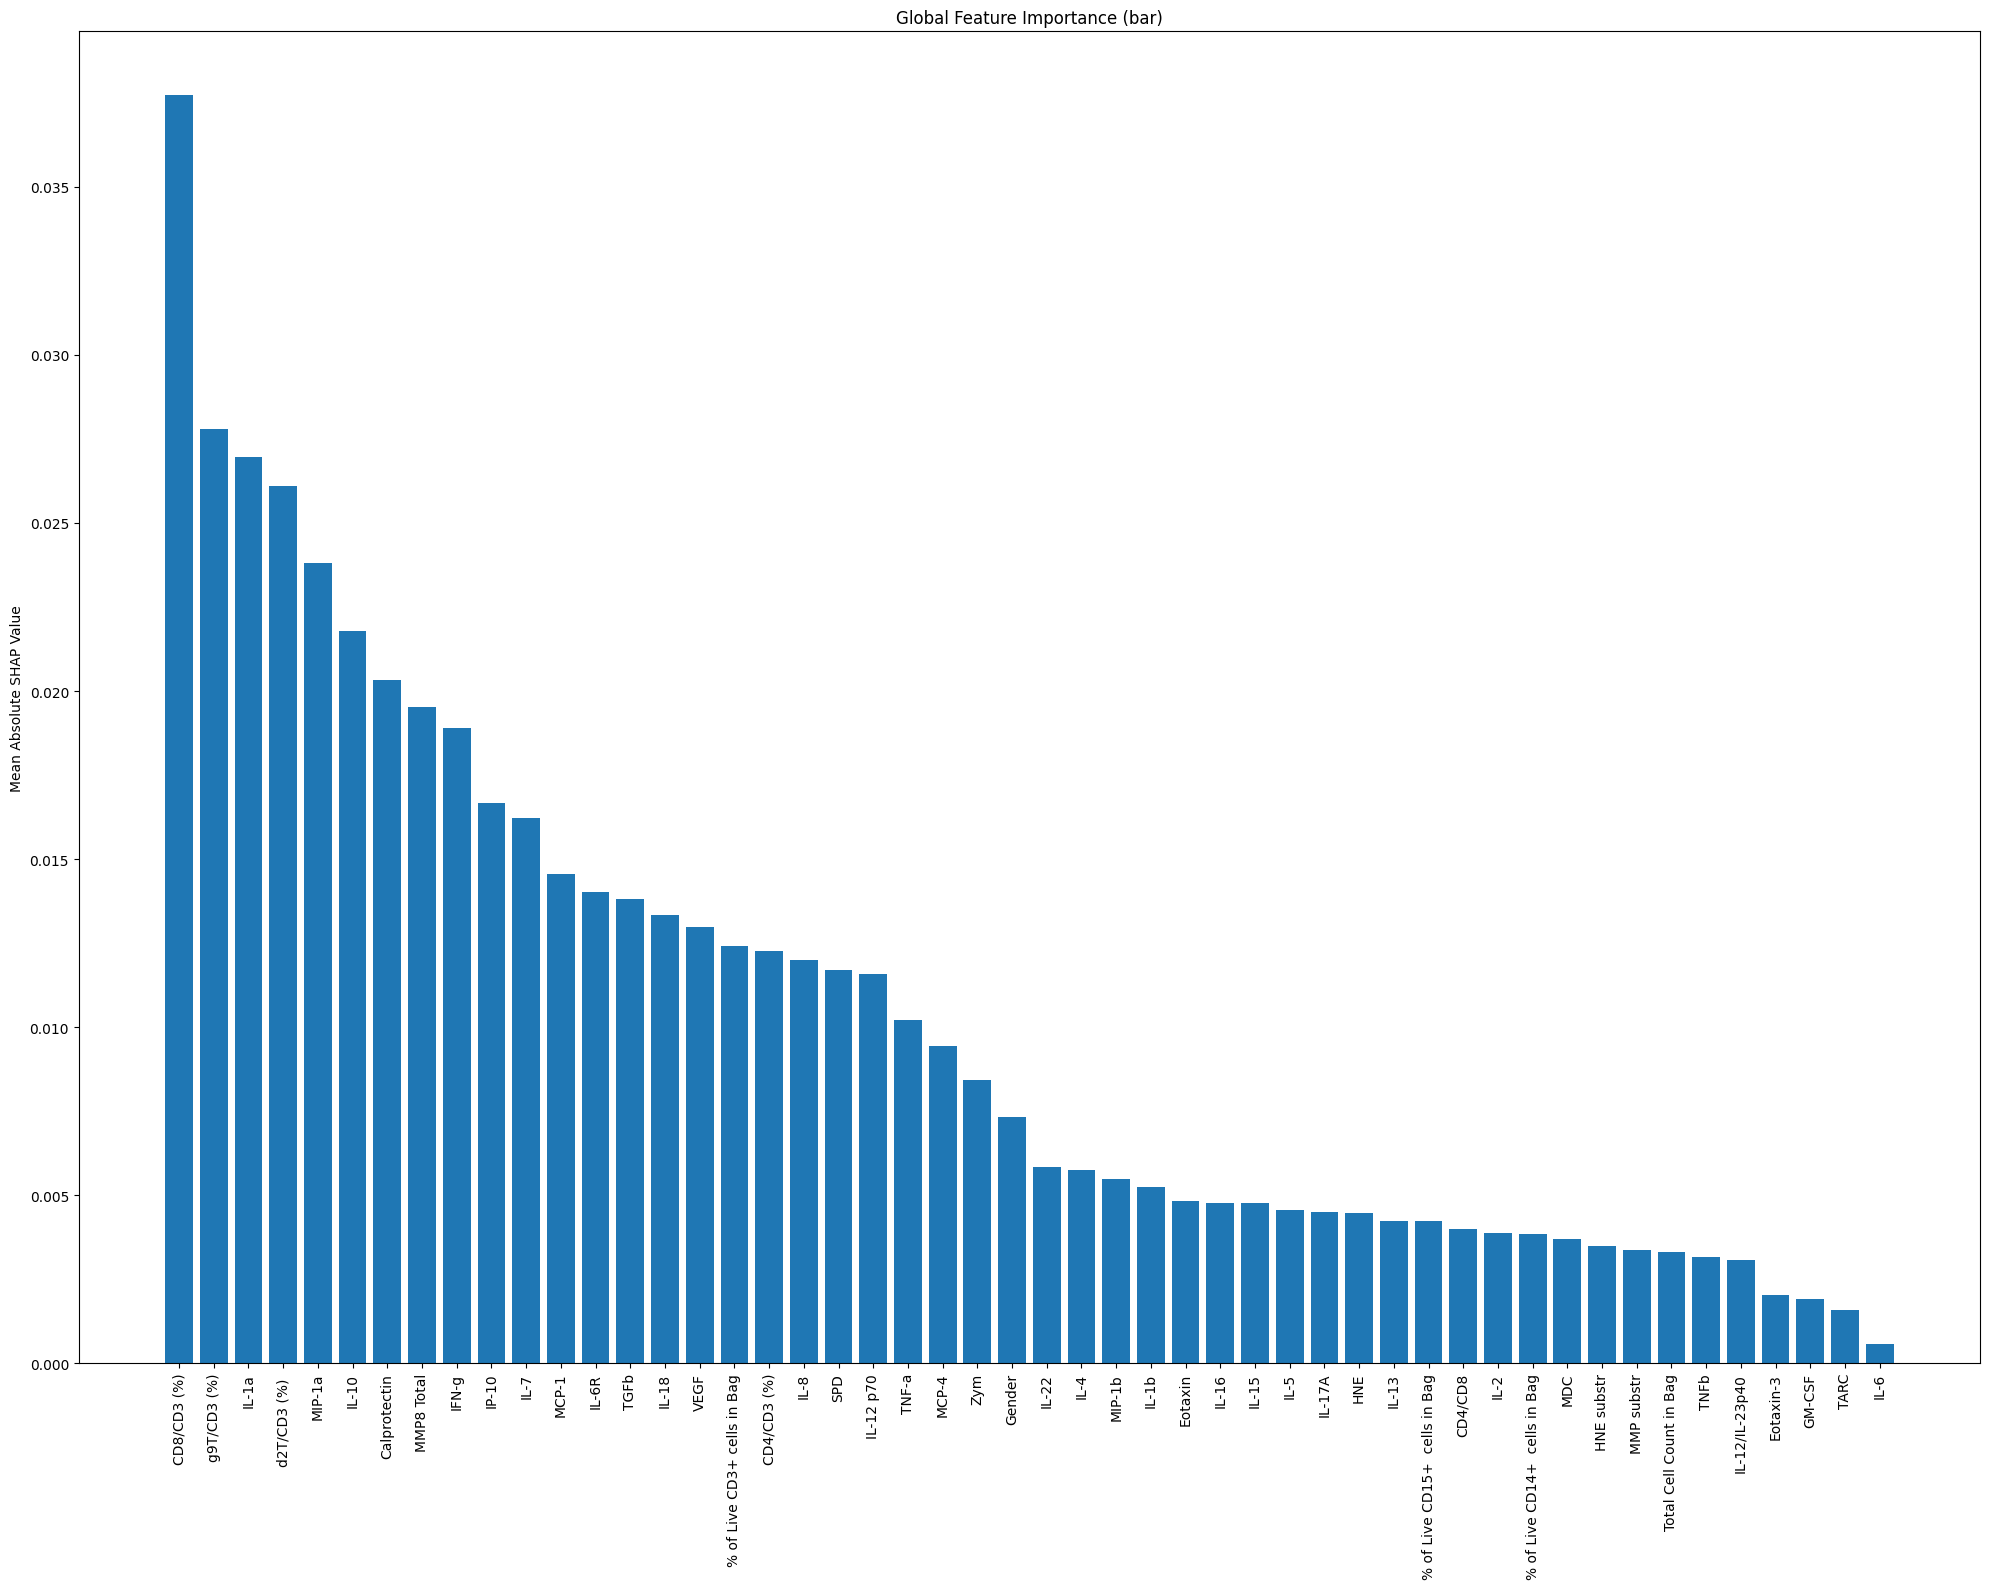

/tmp/ipython-input-2340976278.py:6: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


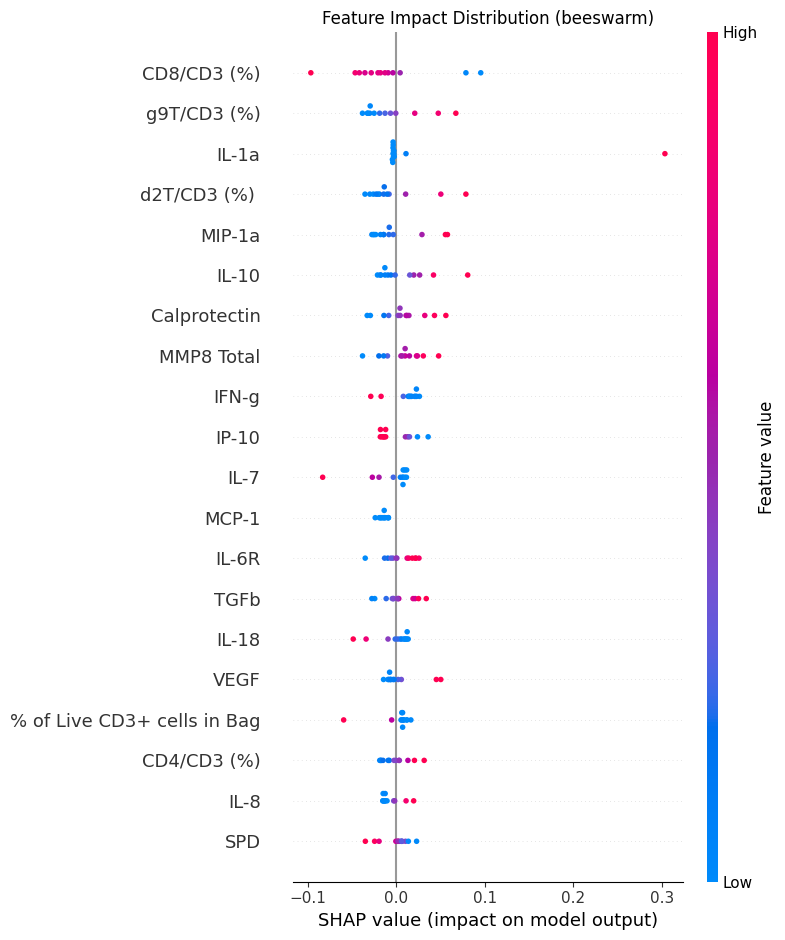

In [ ]:
# Load models
models = load_fold_models(k_folds=5)

# Ensemble predictions
y_pred_proba = ensemble_predict(models, X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

# Evaluate
preds_ensemble_df, metrics_ensemble = evaluate_model(
    y_test=Y_test, y_pred_proba=y_pred_proba, fold_num="ensemble", ids=ids_test
)

print(metrics_ensemble)

# SHAP on Ensemble
ensemble_model = EnsembleWrapper(models)

print(ensemble_model)

ensemble_shap_df, ensemble_shap_values, explanation_shap_ens = compute_shap_values(
    ensemble_model, X_train, X_test, feature_names=X_train.columns, fold_num="Ensemble"
)

# SHAP charts

# explanation_bar = copy.deepcopy(explanation_shap_ens)
# rankings_ensemble = plot_shap_bar(explanation_bar, X_train.columns, fold_num="Ensemble")

explanation_bar = copy.deepcopy(explanation_shap_ens)
shap.plots.bar(explanation_bar)

# print(ensemble_shap_values)

ranking_df = plot_shap_bar(ensemble_shap_values, X_train.columns, fold_num="ensemble")

# print(ensemble_shap_values)


explanation_bee = copy.deepcopy(explanation_shap_ens)
plot_shap_beeswarm(explanation_bee, X_test, X_train.columns)


this shap recompute needs to be done as the folds are loaded back in because otherwise the data has already been seen and this is leaking the test data?

In [ ]:
print(ranking_df)
ranking_df.to_csv("ranking_df.csv", index=False)

        fold                        feature  mean_abs_shap  rank
0   ensemble                    CD8/CD3 (%)       0.037742     1
1   ensemble                    g9T/CD3 (%)       0.027793     2
2   ensemble                          IL-1a       0.026975     3
3   ensemble                   d2T/CD3 (%)        0.026109     4
4   ensemble                         MIP-1a       0.023805     5
5   ensemble                          IL-10       0.021773     6
6   ensemble                   Calprotectin       0.020337     7
7   ensemble                     MMP8 Total       0.019535     8
8   ensemble                          IFN-g       0.018886     9
9   ensemble                          IP-10       0.016671    10
10  ensemble                           IL-7       0.016211    11
11  ensemble                          MCP-1       0.014541    12
12  ensemble                          IL-6R       0.014010    13
13  ensemble                           TGFb       0.013819    14
14  ensemble             

In [ ]:

## SHAP per fold
shap_values_fold_ens = []
for fold_num, model in enumerate(models, start=1):
  shap_df_ens_val, shap_values, explanation = compute_shap_values(
      model,
      X_train, # full background set each fold has seen a variation of this
      X_test, # full test set (ensemble test) which no fold has seen
      feature_names = X_train.columns,
      fold_num=f"fold_{fold_num}"
  )
  shap_df_ens_val["fold"] = fold_num
  shap_df_ens_val["patient_id"] = ids_test.values
  shap_values_fold_ens.append(shap_df_ens_val)

all_folds_shap_on_ens_test = pd.concat(shap_values_fold_ens, axis=0)
all_folds_shap_on_ens_test.to_csv("shap_values_for_folds_on_x_test_ens.csv", index=False)



142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
136/136 ━━━━━━━━━━━━━━━━

PermutationExplainer explainer:  46%|████▌     | 6/13 [00:00<?, ?it/s]

136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


PermutationExplainer explainer:  62%|██████▏   | 8/13 [00:11<00:03,  1.34it/s]

139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


...

PermutationExplainer explainer:  92%|█████████▏| 12/13 [00:18<00:01,  1.48s/it]

141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 100%|██████████| 13/13 [00:20<00:00,  1.71s/it]

145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


PermutationExplainer explainer: 14it [00:23,  2.91s/it]


In [ ]:

# Permutation importance (ensemble mode)
perm_importance_ens_df = compute_permutation_importance(
    X_val=X_test, y_val=Y_test, baseline_metrics=metrics_ensemble,
    evaluate_fn=evaluate_model, ids=ids_test,
    fold_num="ensemble", models=models, ensemble_predict_fn=ensemble_predict
)

# Merge fold + ensemble results
all_folds_predictions = pd.read_csv("all_folds_predictions.csv")
all_folds_shap = pd.read_csv("shap_values_folds.csv")

final_predictions = pd.concat([all_folds_predictions, preds_ensemble_df])
ensemble_shap_df["patient_id"] = ids_test.values
# final_shap = pd.concat([all_folds_shap, ensemble_shap_df])
final_shap = pd.concat([all_folds_shap_on_ens_test, ensemble_shap_df])


# Save
final_predictions.to_csv("all_folds_predictions.csv", index=False)
final_shap.to_csv("all_shap_values.csv", index=False)
perm_importance_ens_df.to_csv("permutation_importance_ensemble.csv", index=False)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━

In [ ]:
perm_importance_ens_df.round(2).to_csv("permutation_importance_ensemble_2dp.csv", index=False)

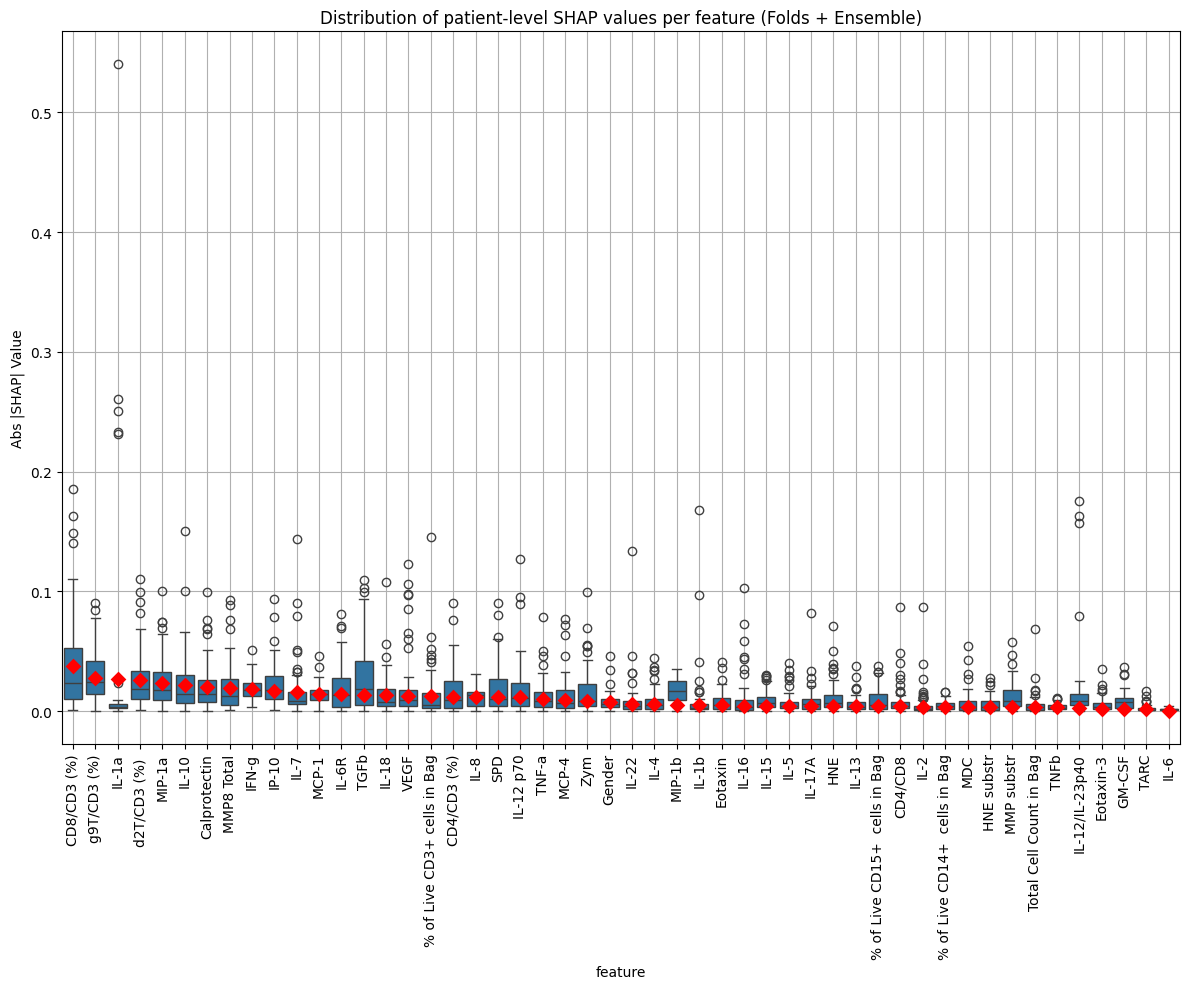

Each box is the distribution of abs SHAP values for each feature across all individual patient samples


In [ ]:

# stats

# Kruskal–Wallis across folds + ensemble
kruskal_ens = compute_kruskal_shap(
    feature_names=X_train.columns,
    final_shap=all_folds_shap_on_ens_test
)
kruskal_ens.to_csv("kruskal_results_ensemble.csv", index=False)

# Absolute version (optional robustness check)
kruskal_abs = compute_kruskal_shap(
    feature_names=X_train.columns,
    final_shap=all_folds_shap_on_ens_test,
    absolute=True
)
kruskal_abs.to_csv("kruskal_importance_results_ensemble.csv", index=False)


final_shap_long = (
    final_shap.drop(columns=["patient_id"], errors="ignore")
    .melt(id_vars="fold", var_name="feature", value_name="shap_value")
)

final_shap_long["abs_shap"] = final_shap_long["shap_value"].abs()

plot_shap_boxplot(final_shap_long)
print("Each box is the distribution of abs SHAP values for each feature across all individual patient samples")

# Global Stats Master Table

### Top 5 features per fold based on SHAP value

In [ ]:
# all_rankings contains all the feature rankings per fold

## go get the top 5 features from each fold

rankings_df = pd.concat(all_rankings, ignore_index=True)

top5_rows = []
for f in sorted(rankings_df["fold"].unique()):
  fold_top5 = (
      rankings_df[rankings_df["fold"] == f].sort_values("rank", ascending=True)
      .head(5)
      .reset_index(drop=True)
  )
  fold_top5["fold"] = f
  top5_rows.append(fold_top5)
top5_df = pd.concat(top5_rows, ignore_index=True)

top5_df.to_csv("top5_features_per_fold.csv", index=False)
print(top5_df)

    fold       feature  mean_abs_shap  rank
0      1   g9T/CD3 (%)       0.080518     1
1      1          TGFb       0.041319     2
2      1   CD8/CD3 (%)       0.041250     3
3      1         IFN-g       0.038449     4
4      1         IL-10       0.031120     5
5      2   CD8/CD3 (%)       0.089974     1
6      2           Zym       0.072497     2
7      2           SPD       0.054154     3
8      2   g9T/CD3 (%)       0.052483     4
9      2  d2T/CD3 (%)        0.049921     5
10     3         IP-10       0.049029     1
11     3        MIP-1a       0.043346     2
12     3         IL-6R       0.034690     3
13     3  d2T/CD3 (%)        0.028091     4
14     3          VEGF       0.027454     5
15     4    MMP8 Total       0.039124     1
16     4  d2T/CD3 (%)        0.035419     2
17     4          IL-8       0.033777     3
18     4        MIP-1a       0.029161     4
19     4         MCP-1       0.025242     5
20     5         IFN-g       0.044189     1
21     5         IL-10       0.0

/tmp/ipython-input-694689475.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq, x="fold", y="feature", palette="viridis")


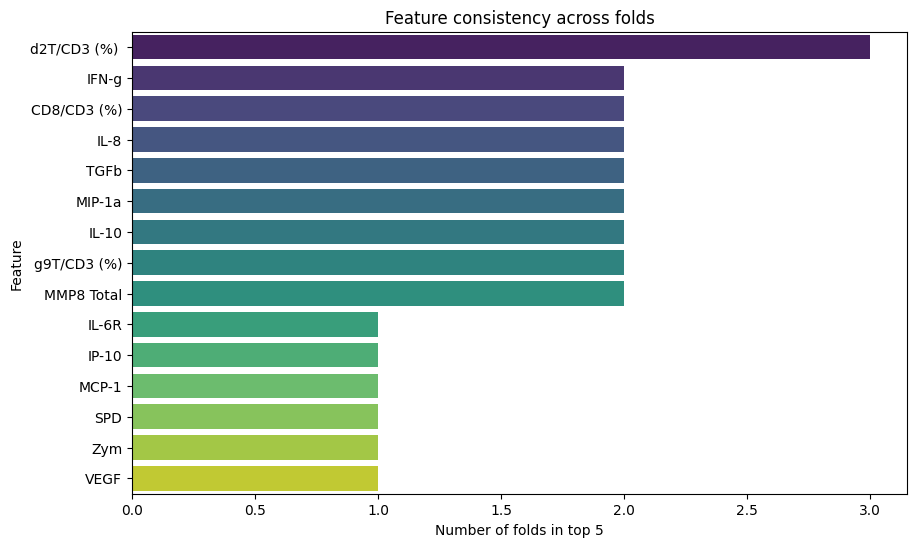

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

freq = top5_df.groupby("feature")["fold"].nunique().reset_index()
freq = freq.sort_values("fold", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=freq, x="fold", y="feature", palette="viridis")
plt.xlabel("Number of folds in top 5")
plt.ylabel("Feature")
plt.title("Feature consistency across folds")
plt.show()

### Top 10

/tmp/ipython-input-1265375686.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=freq, x="fold", y="feature", palette="viridis")


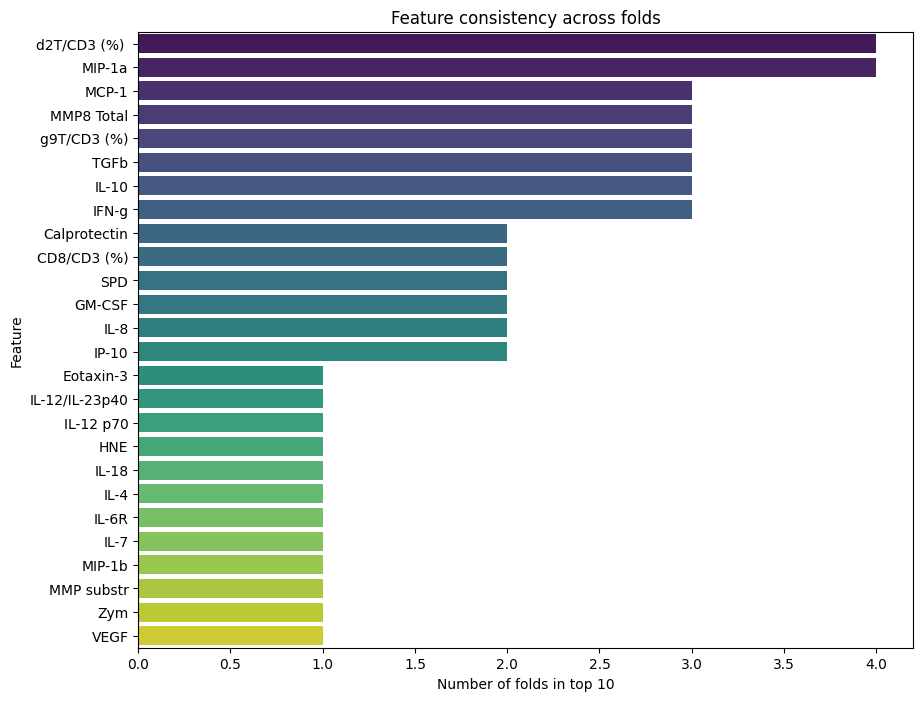

In [ ]:
# all_rankings contains all the feature rankings per fold

## go get the top 10 features from each fold

rankings_df = pd.concat(all_rankings, ignore_index=True)

top10_rows = []
for f in sorted(rankings_df["fold"].unique()):
  fold_top10 = (
      rankings_df[rankings_df["fold"] == f].sort_values("rank", ascending=True)
      .head(10)
      .reset_index(drop=True)
  )
  fold_top10["fold"] = f
  top10_rows.append(fold_top10)
top10_df = pd.concat(top10_rows, ignore_index=True)

top10_df.to_csv("top10_features_per_fold.csv", index=False)

freq = top10_df.groupby("feature")["fold"].nunique().reset_index()
freq = freq.sort_values("fold", ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(data=freq, x="fold", y="feature", palette="viridis")
plt.xlabel("Number of folds in top 10")
plt.ylabel("Feature")
plt.title("Feature consistency across folds")
plt.show()

## Stable vs Unstable features

using ensemble kruskal values

In [ ]:
# 2. Stable vs unstable features (KW)
stable_features = kruskal_ens.sort_values("p_value", ascending=False).head(6)
unstable_features = kruskal_ens.sort_values("p_value", ascending=True).head(6)
stable_features.to_csv("stable_features.csv", index=False)
unstable_features.to_csv("unstable_features.csv", index=False)

print(stable_features)
print(unstable_features)

                          feature  statistic   p_value
43  % of Live CD14+  cells in Bag   0.042604  0.999776
40                            SPD   0.172136  0.996502
32                           TGFb   0.244002  0.993136
4                            IL-4   0.411834  0.981497
44  % of Live CD15+  cells in Bag   0.476385  0.975759
39                   Calprotectin   0.880043  0.927406
                        feature  statistic       p_value
5                          IL-6  42.030769  1.643844e-08
21                       MIP-1b  32.842173  1.286732e-06
26                        MCP-1  30.494244  3.881820e-06
11                        IL-1a  22.450350  1.630135e-04
42  % of Live CD3+ cells in Bag  21.345239  2.704634e-04
10                       GM-CSF  19.194406  7.197456e-04


## Permutation Importance from ensemble

In [ ]:
# 3. Top permutation importance (ensemble)

#print(perm_importance_folds_df)

perm_sorted = perm_importance_ens_df.sort_values("auc_drop", ascending=False)

#print(perm_sorted)

top_perm = perm_sorted.head(10)
top_perm.to_csv("top_permutation_importance.csv", index=False)

print(top_perm)

# for any that improved the accuracy:
perm_improved_accuracy = perm_importance_ens_df.sort_values("auc_drop", ascending=True)
improved_perm = perm_improved_accuracy[perm_improved_accuracy["auc_drop"] < 0]
improved_perm.to_csv("nobueno_perm_imp.csv", index=False)

print(improved_perm)

                        feature  baseline_auc  shuffled_auc  auc_drop  \
49                 d2T/CD3 (%)       0.583333      0.500000  0.083333   
48                  g9T/CD3 (%)      0.583333      0.527778  0.055556   
12                         IL-5      0.583333      0.555556  0.027778   
17                       IL-17A      0.583333      0.555556  0.027778   
40                          SPD      0.583333      0.555556  0.027778   
42  % of Live CD3+ cells in Bag      0.583333      0.555556  0.027778   
23                         TARC      0.583333      0.555556  0.027778   
24                        IP-10      0.583333      0.555556  0.027778   
45                      CD4/CD8      0.583333      0.555556  0.027778   
46                  CD4/CD3 (%)      0.583333      0.555556  0.027778   

    baseline_f1  shuffled_f1   f1_drop  baseline_logloss  shuffled_logloss  \
49     0.736842     0.736842  0.000000          0.657658          0.718686   
48     0.736842     0.705882  0.030960  

# Local Explanations for Critical Cases

## Case selection logic

Critical cases per class (6 patients total):

Strong positive- one patient from each class with a highly confident prediction that is correct

Misclassified- one patient from each class where the predicted label differs from the true label

Borderline- one patient from each class with a prediction probability close to 0.5

Nearest Neighbour comparisons (feature similarity):

This uses a nearest neighbour search to identify pairs of patients that are similar in features. In this case, patients that have slightly different outcomes are found. This gives 2 pairs of comparison cases.

Different predicted outcomes- 2 patients with similar features but divergent ensemble predictions

Different actual classes- 2 patients with different true labels. This could be correct identification (ensemble correctly predicts the class difference) or incorrect identification (the ensemble fails to predict the class difference)

### Critical Cases Per Class

In [ ]:
#print(preds_ensemble_df)
#preds_ensemble_df.sort_values("y_pred_proba", ascending=False).iloc[0]

# strong positive class identification
strong_positive_0 = preds_ensemble_df[(preds_ensemble_df.true==0)].sort_values("prob").iloc[0]
strong_positive_1 = preds_ensemble_df[(preds_ensemble_df.true==1)].sort_values("prob", ascending=False).iloc[0]

# misclassification
misclass_0 = preds_ensemble_df[(preds_ensemble_df.true==0) & (preds_ensemble_df.pred==1)].iloc[0]
misclass_1 = preds_ensemble_df[(preds_ensemble_df.true==1) & (preds_ensemble_df.pred==0)].iloc[0]

# borderline case

borderline_0 = preds_ensemble_df.loc[preds_ensemble_df["true"] == 0, :].iloc[(preds_ensemble_df.loc[preds_ensemble_df["true"] == 0, "prob"] - 0.5).abs().argmin()]
borderline_1 = preds_ensemble_df.loc[preds_ensemble_df["true"] == 1, :].iloc[(preds_ensemble_df.loc[preds_ensemble_df["true"] == 1, "prob"] - 0.5).abs().argmin()]


print(strong_positive_0)

patient_id       020-1
fold          ensemble
true                 0
pred                 0
prob          0.321879
Name: 0, dtype: object


### Nearest Neighbour Comparisons

In [ ]:
# Nearest neighbour pairs
from sklearn.neighbors import NearestNeighbors

nearestn = NearestNeighbors(n_neighbors=5, metric="euclidean")
nearestn.fit(X_test)

distances, indices = nearestn.kneighbors(X_test)
pairs = []

for i, neighs in enumerate(indices):
  for k, j in enumerate(neighs[1:]): # skips self

    dist = distances[i][k+1] # distance to neighbour

    if preds_ensemble_df.iloc[i].pred != preds_ensemble_df.iloc[j].pred:
      pairs.append(("diff_predicted", i, j, dist))
    elif preds_ensemble_df.iloc[i].true != preds_ensemble_df.iloc[j].true:
      if preds_ensemble_df.iloc[i].pred == preds_ensemble_df.iloc[i].true and preds_ensemble_df.iloc[j].pred == preds_ensemble_df.iloc[j].true:
        pairs.append(("diff_true_correct", i, j, dist))
      else:
        pairs.append(("diff_true_incorrect", i, j, dist))


pairs_with_ids = [
    (category,
     preds_ensemble_df.iloc[i]["patient_id"],
     preds_ensemble_df.iloc[j]["patient_id"],
     dist)
    for category, i, j, dist in pairs
]

## SHAP and LIME plots

In [ ]:
# get patient IDs

selected_ids = [
    strong_positive_0["patient_id"],
    strong_positive_1["patient_id"],
    misclass_0["patient_id"],
    misclass_1["patient_id"],
    borderline_0["patient_id"],
    borderline_1["patient_id"]
]

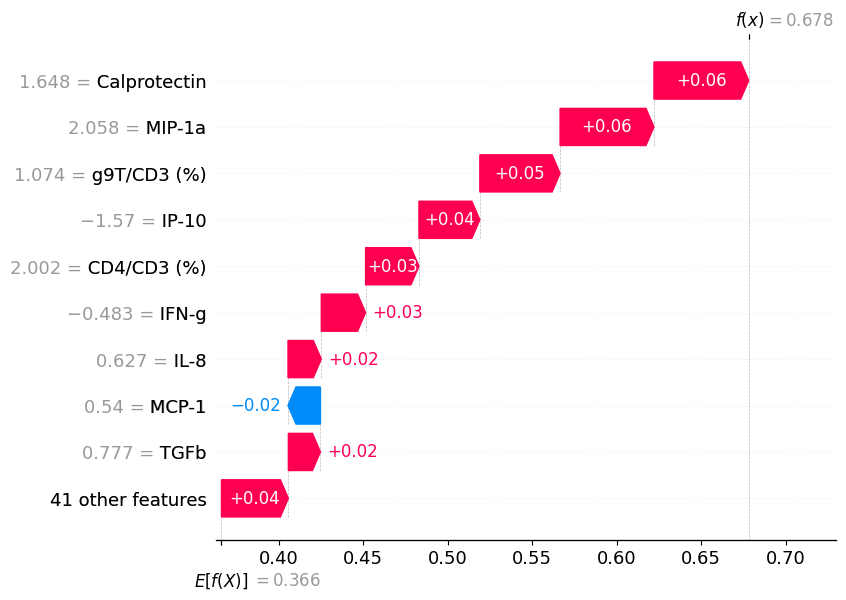

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


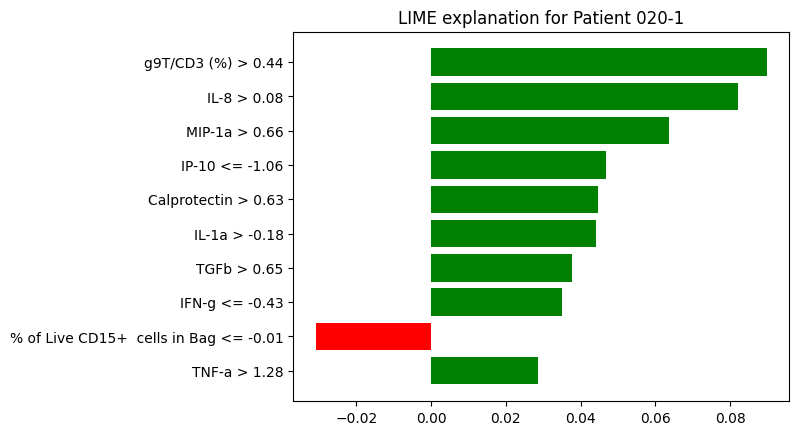

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Available labels:  [np.int64(0)]
{'g9T/CD3 (%)': np.float64(0.08329441735685965), 'IL-8': np.float64(0.08145415842822269), 'MIP-1a': np.float64(0.06375888340008469), 'IL-1a': np.float64(0.0568686105756207), 'Calprotectin': np.float64(0.051939475696037886), 'IP-10': np.float64(0.03812431701795504), 'TGFb': np.float64(0.0347682105627857), 'CD4/CD3 (%)': np.float64(0.03402585229373767), 'TNF-a': np.float64(0.032510740399876406), '% of Live CD15+  cells in Bag': np.float64(-0.028272635879979)}
{'Gender': np.float64(0.015494138449430463), 'IFN-g': np.float64(0.026204127371311177), 'IL-1b': np.float64(0.0022560515999793945), 'IL-2': np.float64(0.0028934788703918607), 'IL-4': np.float64(-0.006514825373887985), 'IL-6': np.float64(-0.0007372924685478399), 'IL-10': np.float64(-0.006015559583902

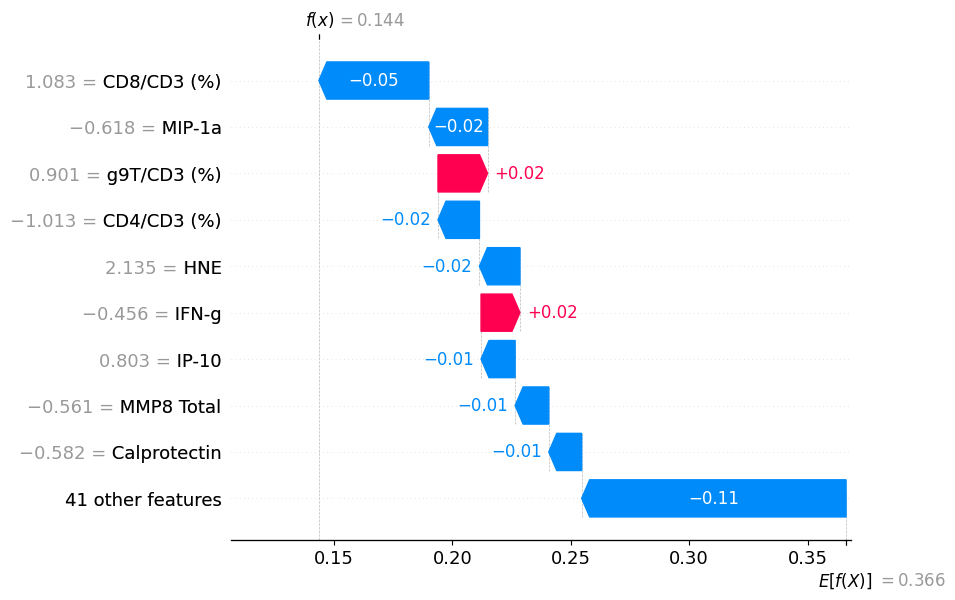

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


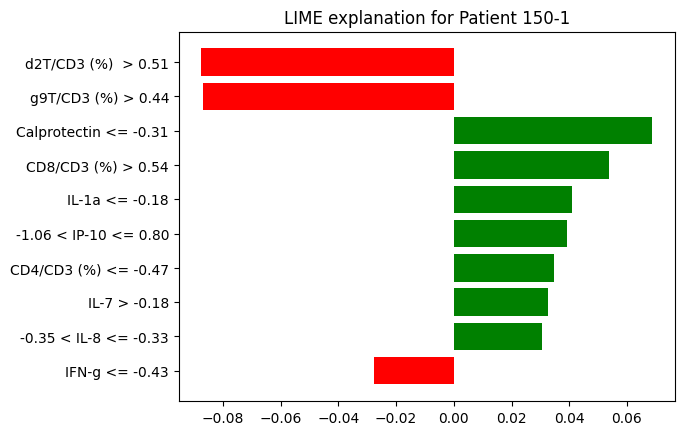

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Available labels:  [np.int64(1)]
{'g9T/CD3 (%)': np.float64(-0.08238911800019758), 'd2T/CD3 (%) ': np.float64(-0.08153964582491834), 'Calprotectin': np.float64(0.06324380365901981), 'CD8/CD3 (%)': np.float64(0.060276813595733156), 'IL-1a': np.float64(0.04498197694209735), 'IP-10': np.float64(0.04124905653241741), 'IFN-g': np.float64(-0.0402648776935297), 'IL-7': np.float64(0.03635784166683797), 'CD4/CD3 (%)': np.float64(0.03400619137149015), 'MIP-1a': np.float64(0.027992637844016226)}
{'Gender': np.float64(-0.005253242850303659), 'IFN-g': np.float64(0.016430931091308592), 'IL-1b': np.float64(-0.0003206752240657654), 'IL-2': np.float64(0.0020603230595588815), 'IL-4': np.float64(-0.009997074902057645), 'IL-6': np.float64(-0.0013283117115497727), 'IL-10': np.float64(-0.00934855028986932)

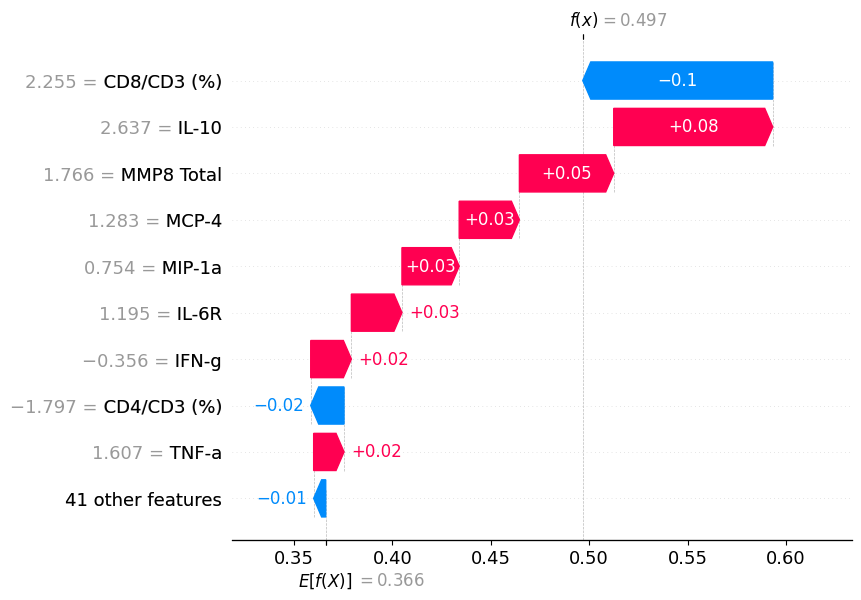

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


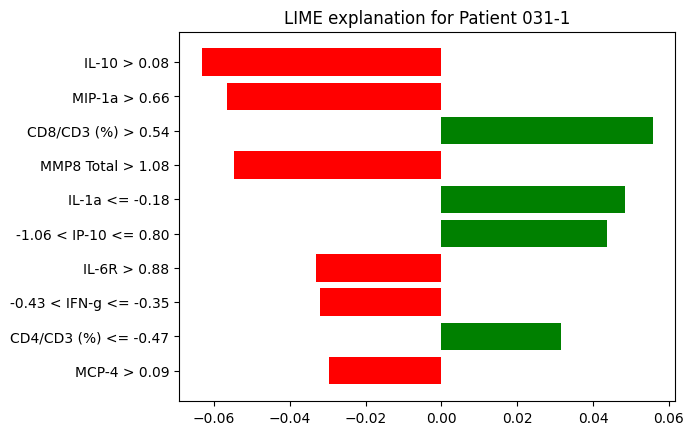

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Available labels:  [np.int64(1)]
{'MIP-1a': np.float64(-0.06632584810745416), 'IL-10': np.float64(-0.06314421425694003), 'CD8/CD3 (%)': np.float64(0.059479101850232044), 'IL-1a': np.float64(0.05832720387140462), 'IP-10': np.float64(0.04198367636478787), 'TNF-a': np.float64(-0.03669723092202824), 'MCP-4': np.float64(-0.03518862467934194), 'MMP8 Total': np.float64(-0.03438864062939278), 'IL-6R': np.float64(-0.03404861330564947), 'IL-17A': np.float64(0.030270146092051007)}
{'Gender': np.float64(0.01308298185467719), 'IFN-g': np.float64(0.02063464745879174), 'IL-1b': np.float64(-0.0022013968229293718), 'IL-2': np.float64(0.002832702100276939), 'IL-4': np.float64(-0.001421875655651092), 'IL-6': np.float64(-0.0004193352162837963), 'IL-10': np.float64(0.08073995575308801), 'IL-12 p70': np.fl

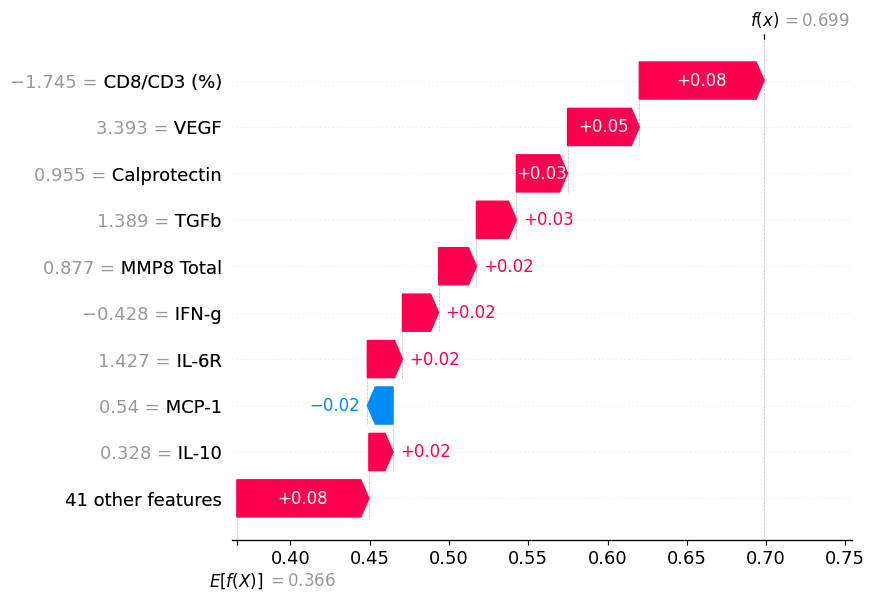

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


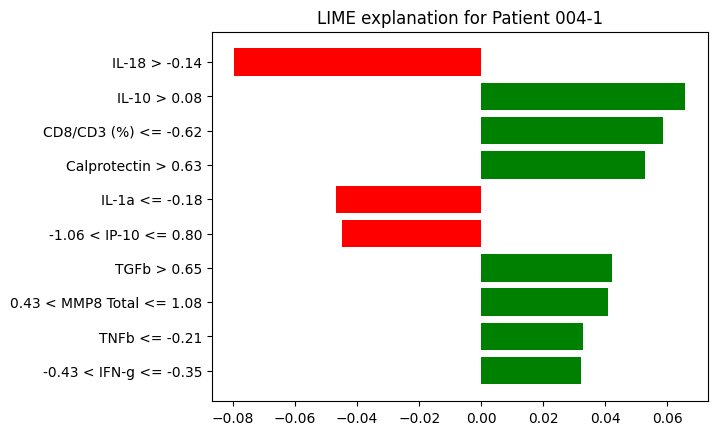

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
Available labels:  [np.int64(0)]
{'IL-18': np.float64(-0.06604901483464436), 'IL-10': np.float64(0.06586109383820812), 'IL-1a': np.float64(-0.054947052543114626), 'Calprotectin': np.float64(0.053077510312269004), 'CD8/CD3 (%)': np.float64(0.04821815913783861), 'IP-10': np.float64(-0.047047955358978565), 'MMP8 Total': np.float64(0.03275831607865894), 'TGFb': np.float64(0.032565472050874025), 'SPD': np.float64(-0.030523376521970392), 'IL-6R': np.float64(0.030340153455963602)}
{'Gender': np.float64(-0.006007795780897135), 'IFN-g': np.float64(0.022783172875642785), 'IL-1b': np.float64(0.0042268660664558436), 'IL-2': np.float64(0.003964358717203131), 'IL-4': np.float64(0.006933294832706459), 'IL-6': np.float64(-0.00012794166803360013), 'IL-10': np.float64(0.015269574224948887), 'IL-12 p70

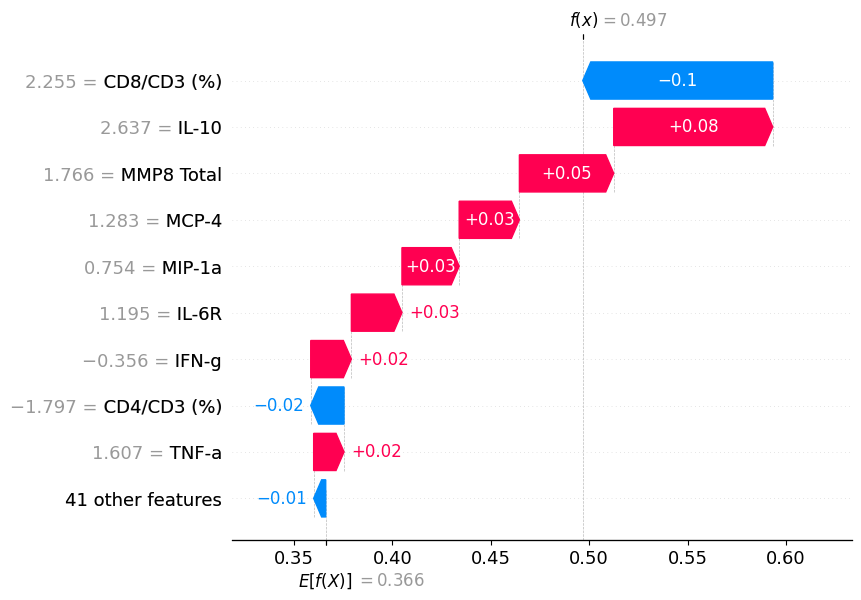

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step


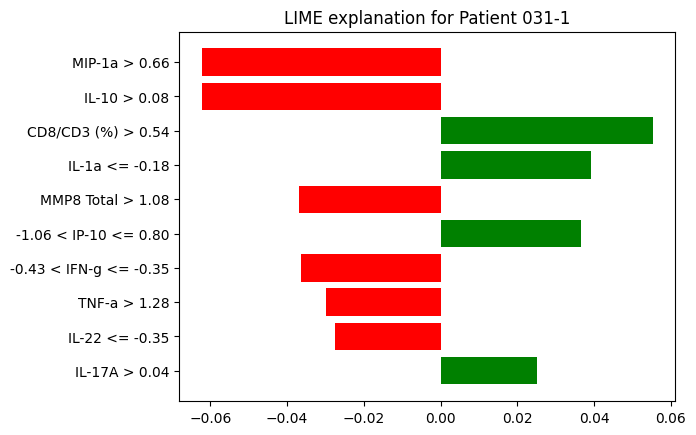

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Available labels:  [np.int64(1)]
{'MIP-1a': np.float64(-0.06326340541858907), 'CD8/CD3 (%)': np.float64(0.06091912436434443), 'IL-10': np.float64(-0.05681958476254683), 'IP-10': np.float64(0.04136095926288273), 'IL-6R': np.float64(-0.039085187545018114), 'MMP8 Total': np.float64(-0.038670468885187194), 'MCP-4': np.float64(-0.03736944286764445), 'IL-17A': np.float64(0.036800143233676495), 'CD4/CD3 (%)': np.float64(0.031799065545695886), 'IL-1a': np.float64(0.03140865977772912)}
{'Gender': np.float64(0.01308298185467719), 'IFN-g': np.float64(0.02063464745879174), 'IL-1b': np.float64(-0.0022013968229293718), 'IL-2': np.float64(0.002832702100276939), 'IL-4': np.float64(-0.001421875655651092), 'IL-6': np.float64(-0.0004193352162837963), 'IL-10': np.float64(0.08073995575308801), 'IL-12 p

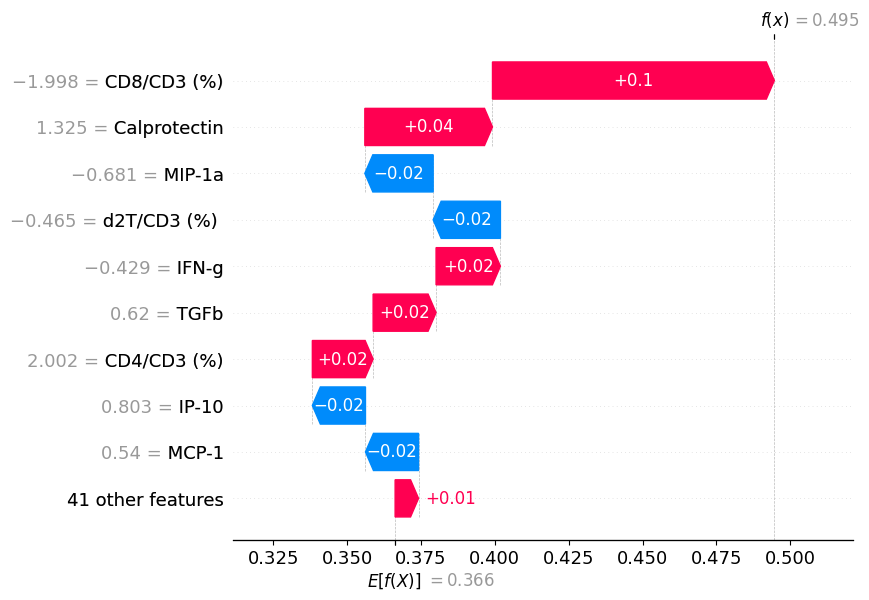

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


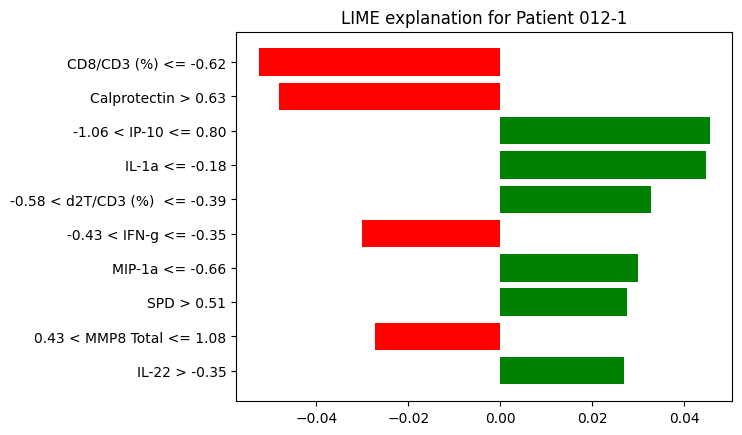

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Available labels:  [np.int64(1)]
{'CD8/CD3 (%)': np.float64(-0.05593593768028829), 'IL-1a': np.float64(0.04961870424064231), 'IP-10': np.float64(0.04824282007859414), 'Calprotectin': np.float64(-0.045123876184362734), 'MIP-1a': np.float64(0.03504830311521077), 'd2T/CD3 (%) ': np.float64(0.03181204454104487), 'MMP8 Total': np.float64(-0.02898204567655167), 'IL-18': np.float64(-0.02495855550077103), 'CD4/CD3 (%)': np.float64(-0.02372156351967661), 'IFN-g': np.float64(-0.02290194817852059)}
{'Gender': np.float64(-0.0037751130759716076), 'IFN-g': np.float64(0.021793260872364037), 'IL-1b': np.float64(-0.0002821558713913125), 'IL-2': np.float64(0.0027294933795928775), 'IL-4': np.float64(-0.00019639864563938958), 'IL-6': np.float64(-7.704034447669761e-05), 'IL-10': np.float64(-0.012604018002

In [ ]:
lime_explainer = build_lime_explainer(
    X_train=X_train,
    feature_names=X_train.columns,
    class_names=["Negative", "Positive"]
)

for pid in selected_ids:
  idx = preds_ensemble_df.index[preds_ensemble_df["patient_id"] == pid][0]
  # pass ids to shap plots
  # print(idx)

  ## SHAP Waterfall

  plot_shap_waterfall(explanation_shap_ens, preds_ensemble_df, pid)

  # plt.title(f"Feature impacts for Patient {pid}")

  # pass ids to LIME plots
  plot_lime_for_patient(
      explainer= lime_explainer,
      model=ensemble_model,
      X_data=X_test,
      preds_df=preds_ensemble_df,
      patient_id=pid,
      num_features=10
  )
  # plt.title(f"LIME explanation for patient {pid}")

  # Get raw LIME values for stats
  lime_expl = lime_explainer.explain_instance(
      X_test.iloc[idx].values,
      ensemble_model.predict,
      num_features=10,
      top_labels=1
  )
  # pred_label = np.argmax(ensemble_model.predict(X_test.iloc[idx].values.reshape(1, -1)))
  ## above is wrong as this works for multiclass but i am doing binary class

  print("Available labels: ", lime_expl.available_labels())

  idx_weights = lime_expl.as_map()[lime_expl.available_labels()[0]] # LIME weights
  features = X_test.columns.tolist()
  lime_dict = {features[i]: w for i, w in idx_weights}
  # print("LIME values:")
  # print(lime_dict)

  # SHAP values for patient idx
  shap_vals_patient = explanation_shap_ens[idx].values # array of feature contributions
  features = X_test.columns.tolist()
  shap_dict = dict(zip(features, shap_vals_patient))
  print(lime_dict)
  print(shap_dict)

  # # Intersection of features
  common_feats = set(lime_dict.keys()) & set(shap_dict.keys())

  ## Use the lime weights as a comparitor to SHAP values to compare the magnitue
  if len(common_feats) > 0:
    # sort the list:
    ordered_common_feats = sorted(common_feats)

    ## for the features in common features, pull the LIME weight and SHAP value
    comparison_df = pd.DataFrame({
        "Feature": ordered_common_feats,
        "LIME": [lime_dict[f] for f in ordered_common_feats],
        "SHAP": [shap_dict[f] for f in ordered_common_feats]
    })
    print(comparison_df)

    ## Magnitude ranking
    from scipy.stats import spearmanr

    ## abs gets rid of the sign so this test effectively compares if lime and shap agree on
    ## which features are the most important

    comparison_df["LIME_rank"] = comparison_df["LIME"].abs().rank()
    comparison_df["SHAP_rank"] = comparison_df["SHAP"].abs().rank()

    rho, p_rho = spearmanr(comparison_df["LIME_rank"], comparison_df["SHAP_rank"])
    print("Spearman Rank correlation between how lime ranked the features and how shap ranked the features")
    print(f"rho={rho:.3f}, p={p_rho:.4f}")

    ## Direction (sign agreement)

    ## this compares if LIME and SHAP agree on the direction a feature pushes the prediction
    ## does the same feature push the prediction up or down

    comparison_df["LIME_sign"] = np.sign(comparison_df["LIME"])
    comparison_df["SHAP_sign"] = np.sign(comparison_df["SHAP"])
    print(comparison_df[["Feature", "LIME", "SHAP", "LIME_sign", "SHAP_sign"]])

    from sklearn.metrics import cohen_kappa_score
    import numpy as np


    # simple agreement
    direction_agreement = (comparison_df["LIME_sign"] == comparison_df["SHAP_sign"]).mean()
    print(f"Direction agreement: {direction_agreement:.2%}")

    # chance-corrected agreement
    kappa = cohen_kappa_score(comparison_df["LIME_sign"], comparison_df["SHAP_sign"])
    print(f"Cohen’s kappa: {kappa:.3f}")


    # stats, p = wilcoxon(comparison_df["SHAP"], comparison_df["LIME"])
  #   print(f"Patient {pid}: Wilcoxon p = {p:.4f}")
  # else:
  #   print(f"Patient {pid}: no overlapping features between LIME and SHAP to compare")

### JESS THE ISSUE WITH ONLY 10 SHOWING IS YOU DO LIME ON THE TOP 10 FEATURES BUT SHAP ON ALL THE FEATURES THAT IS THE PROBLEM LOLLLL

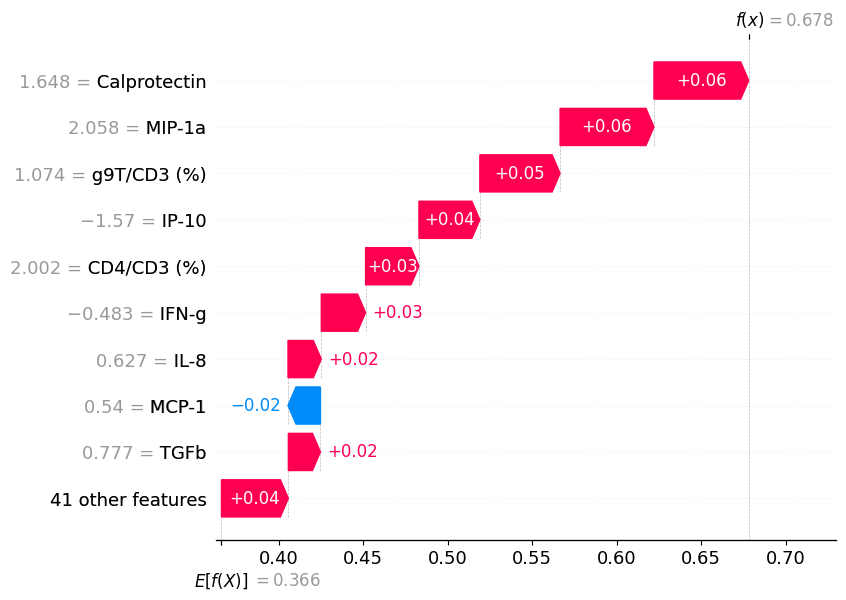

157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


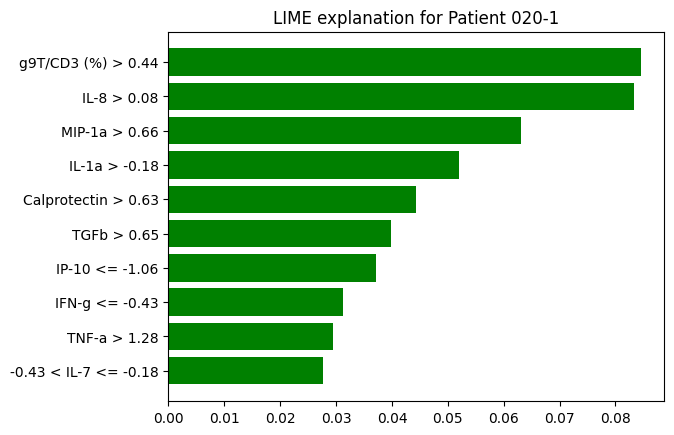

Spearman rho=0.564, p=0.0897
Direction agreement: 100.00%
Cohen’s kappa: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:758: RuntimeWarning: invalid value encountered in scalar divide
  k = np.sum(w_mat * confusion) / np.sum(w_mat * expected)


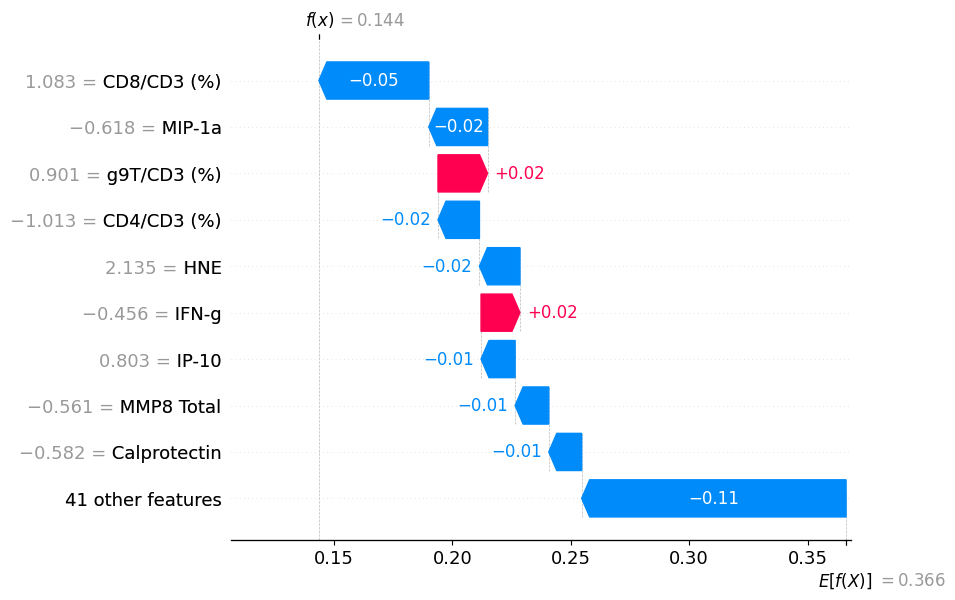

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step


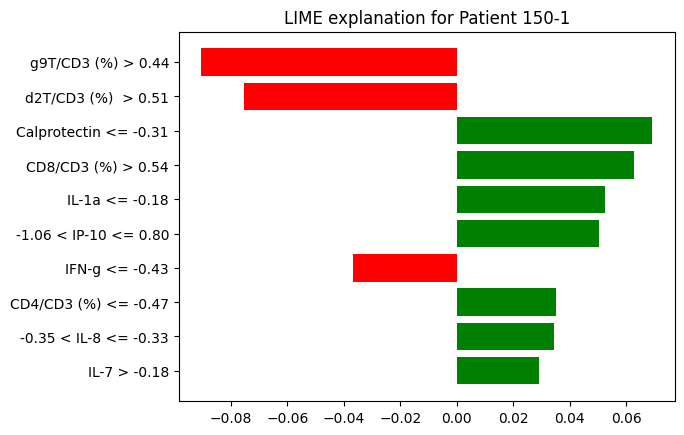

Spearman rho=0.418, p=0.2291
Direction agreement: 0.00%
Cohen’s kappa: -0.724


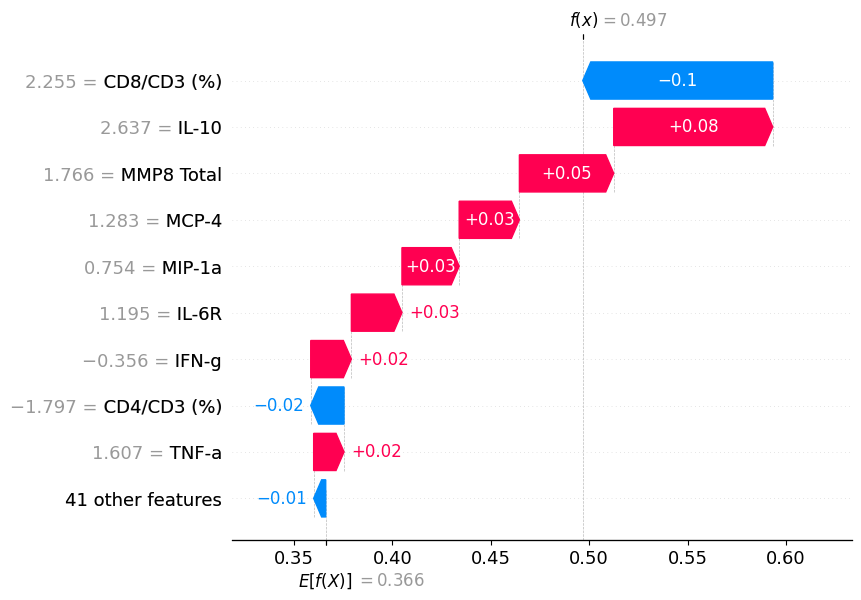

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


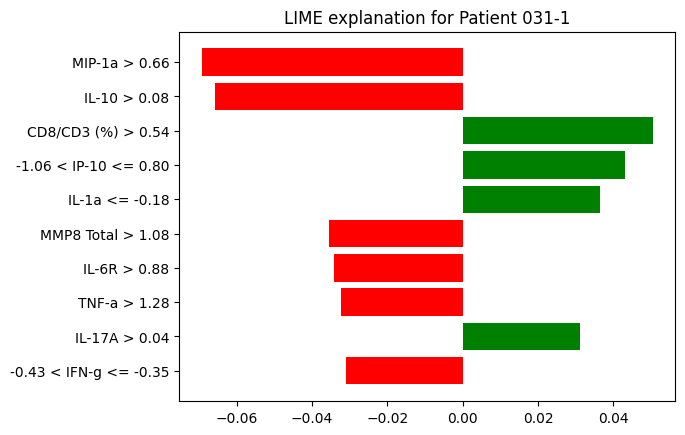

Spearman rho=0.539, p=0.1076
Direction agreement: 10.00%
Cohen’s kappa: -0.667


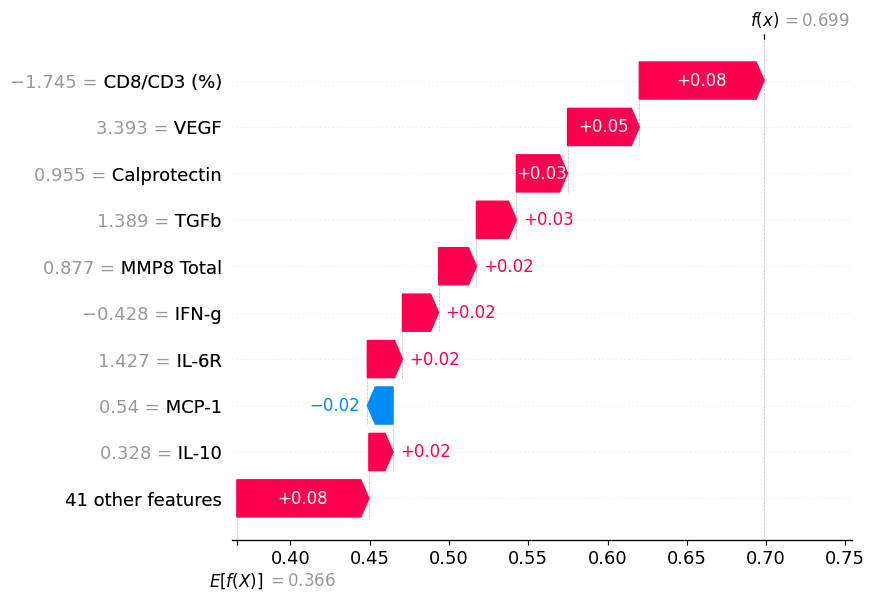

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


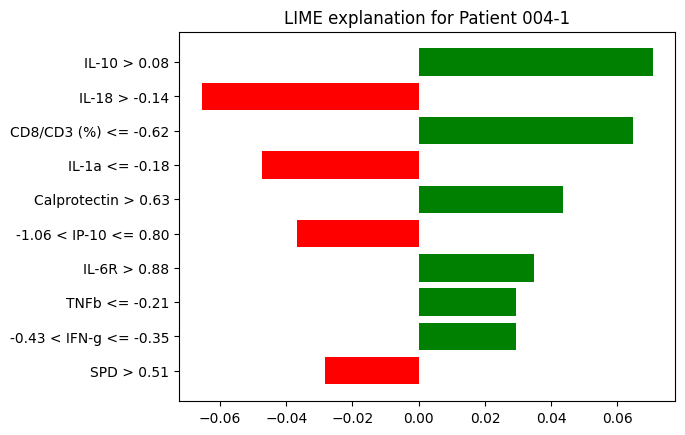

Spearman rho=0.152, p=0.6761
Direction agreement: 80.00%
Cohen’s kappa: 0.545


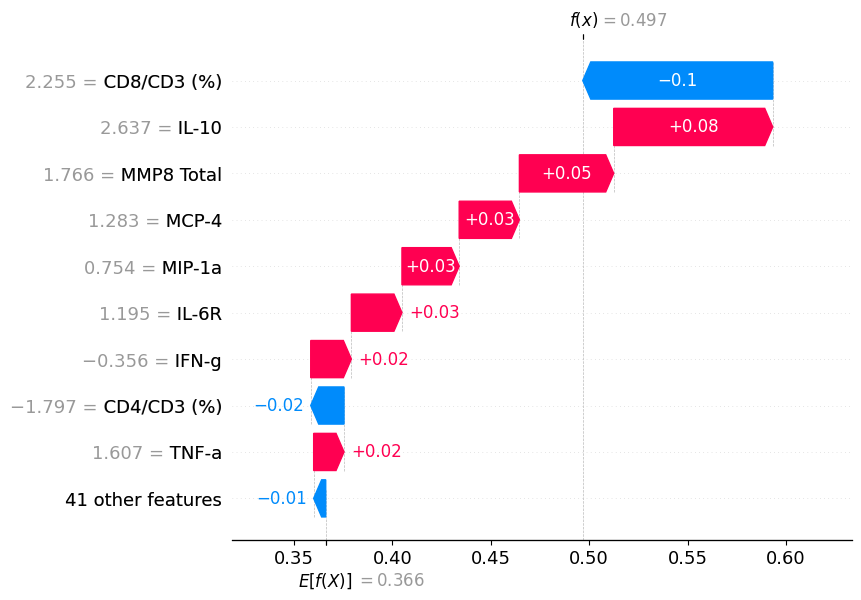

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


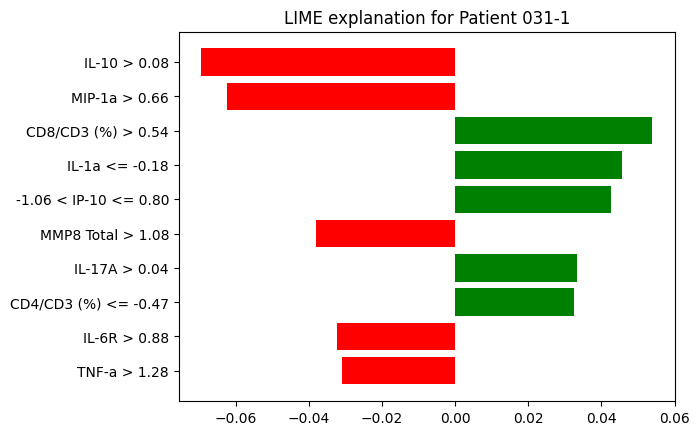

Spearman rho=0.455, p=0.1869
Direction agreement: 10.00%
Cohen’s kappa: -0.800


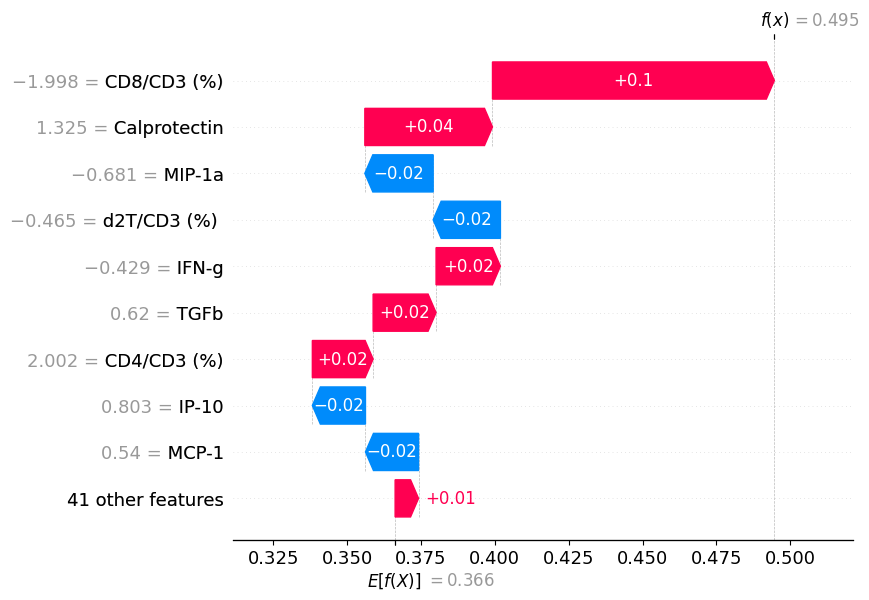

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


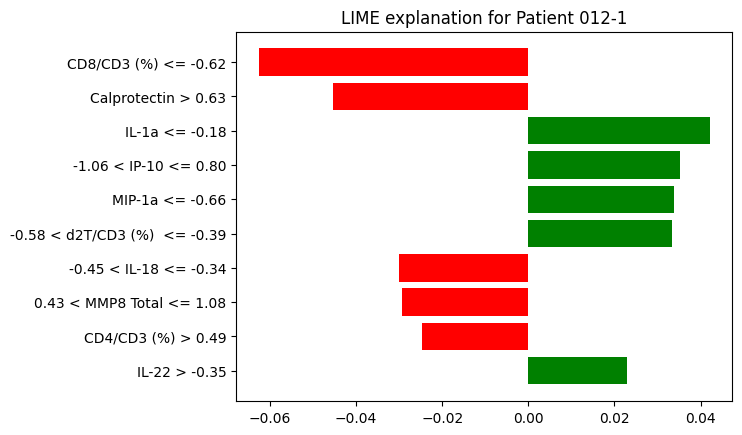

Spearman rho=0.600, p=0.0667
Direction agreement: 0.00%
Cohen’s kappa: -1.000


In [ ]:
# Initialise LIME explainer
lime_explainer = build_lime_explainer(
    X_train=X_train,
    feature_names=X_train.columns,
    class_names=["Negative", "Positive"]
)

feature_names = X_test.columns.tolist()

for pid in selected_ids:

    # --- Identify patient row ---
    idx = preds_ensemble_df.index[preds_ensemble_df["patient_id"] == pid][0]
    x_instance = X_test.iloc[idx].values.reshape(1, -1)

    # --- SHAP waterfall plot ---
    plot_shap_waterfall(explanation_shap_ens, preds_ensemble_df, pid)

    # --- SHAP values for this patient ---
    shap_vals_patient = explanation_shap_ens[idx].values
    shap_dict = dict(zip(feature_names, shap_vals_patient))

    # --- LIME explanation ---
    lime_expl = lime_explainer.explain_instance(
        X_test.iloc[idx].values,
        ensemble_model.predict,
        num_features=10,
        top_labels=1
    )

    # Extract LIME weights
    label = lime_expl.available_labels()[0]
    idx_weights = lime_expl.as_map()[label]
    lime_dict = {feature_names[i]: w for i, w in idx_weights}

    # --- Plot LIME explanation ---
    # Corrected line: Access the probability of the positive class (index [0, 1])
    pred_label = int(ensemble_model.predict(x_instance)[0, 1] > 0.5)
    fig = lime_expl.as_pyplot_figure(label=pred_label)
    plt.title(f"LIME explanation for Patient {pid}")
    plt.show()

    # --- Compare LIME vs SHAP ---
    common_feats = set(lime_dict.keys()) & set(shap_dict.keys())
    if len(common_feats) == 0:
        continue

    ordered = sorted(common_feats)
    comparison_df = pd.DataFrame({
        "Feature": ordered,
        "LIME": [lime_dict[f] for f in ordered],
        "SHAP": [shap_dict[f] for f in ordered]
    })

    # Magnitude ranking comparison
    comparison_df["LIME_rank"] = comparison_df["LIME"].abs().rank()
    comparison_df["SHAP_rank"] = comparison_df["SHAP"].abs().rank()

    rho, p_rho = spearmanr(comparison_df["LIME_rank"], comparison_df["SHAP_rank"])
    print(f"Spearman rho={rho:.3f}, p={p_rho:.4f}")

    # Direction (sign) agreement
    comparison_df["LIME_sign"] = np.sign(comparison_df["LIME"])
    comparison_df["SHAP_sign"] = np.sign(comparison_df["SHAP"])

    direction_agreement = (comparison_df["LIME_sign"] == comparison_df["SHAP_sign"]).mean()
    kappa = cohen_kappa_score(comparison_df["LIME_sign"], comparison_df["SHAP_sign"])

    print(f"Direction agreement: {direction_agreement:.2%}")
    print(f"Cohen’s kappa: {kappa:.3f}")

# SHAP Dependence for key features

## Model relies on these globaly (top 3)

CD8/CD3 (%)


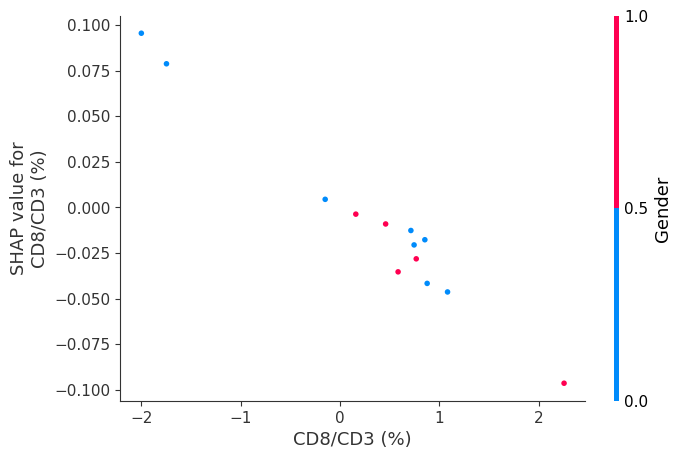

g9T/CD3 (%)


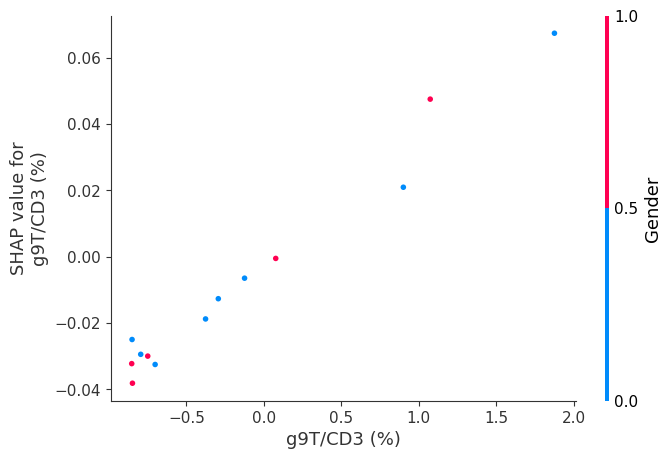

IL-1a


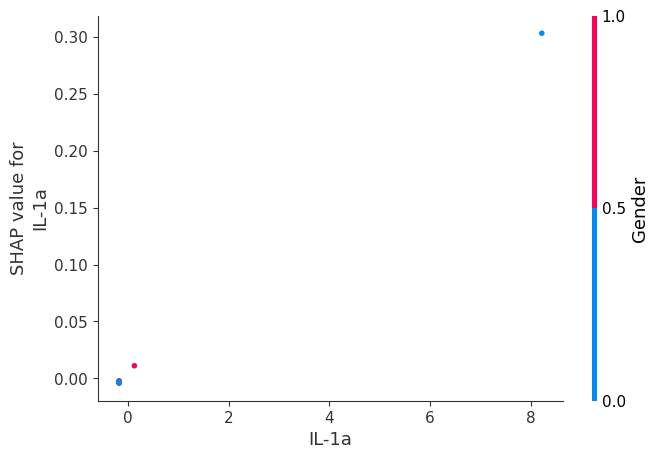

In [ ]:
# print(ranking_df)

top3_global = ranking_df["feature"].head(3).tolist()
# print(top3_global)

# print(X_test.columns.tolist())

# print(ensemble_shap_values.shape)
# print(shap_values)
# print(X_test.shape)

for f in top3_global:
  print(f)
  plot_shap_dependence(f, ensemble_shap_values, X_test)

# Integrated Gradients

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd

print("XTest :", X_test)

def integrated_gradients(model, x, baseline=None, steps=50):
    """
    Compute Integrated Gradients for a binary sigmoid model.

    Parameters
    ----------
    model : tf.keras.Model
        A trained Keras model with 1 sigmoid output.
    x : np.array
        Input samples, shape (n_samples, n_features).
    baseline : np.array
        Baseline input, same shape as x. Defaults to zeros.
    steps : int
        Number of interpolation steps.

    Returns
    -------
    ig : np.array
        Integrated Gradient attributions, shape (n_samples, n_features).
    """
    x = tf.convert_to_tensor(x, dtype=tf.float32)
    if baseline is None:
        baseline = tf.zeros_like(x)
    else:
        baseline = tf.convert_to_tensor(baseline, dtype=tf.float32)

    # interpolate along the path
    alphas = tf.linspace(0.0, 1.0, steps)
    ## Create steps (evenly spaced values) between 0 and 0.1- these are the interpolation coefficients for moving from basline to input
    alphas_x = baseline[None, ...] + alphas[:, None, None] * (x[None, ...] - baseline[None, ...])
    ## basically, add new leading dimension so baseline can be broadcast across steps
    ### then do the difference between input and baseline, also with a leading dimension
    #### Then reshape the alphas so each aplpha applies across all samples and features

    # the result is a tensor of shap [steps, n_samples, n_features] which is all the points along the straightline from baseline to x


    with tf.GradientTape() as tape: # keep operations for gradients later
        tape.watch(alphas_x) # tells tensorflow to track alphas_x because I want the gradients with respect to these interpolated inputs
        preds = model(tf.reshape(alphas_x, (-1, x.shape[1])))  # forward pass

        ## squish into 2D, then run the model on the interpolated points and return predictions

        preds_tf = tf.reshape(preds, (steps, x.shape[0], -1))[:, :, 0]  # single sigmoid output
        preds_mean = tf.reduce_mean(preds_tf, axis=0)  # [n_samples]
        ## this averages the predictions across all steps for each sample
        #### returns a single sample representing the average prediction along the path
    grads = tape.gradient(preds_mean, alphas_x)
    ## This computes the gradient

    avg_grads = tf.reduce_mean(grads, axis=0)  # [n_samples, n_features]
    ## This part averages the gradients over the steps dimension, and returns the average gradient for each feature of each sample
    ig = (x - baseline) * avg_grads
    return ig.numpy()

# --- Run IG per fold model ---
ig_all_folds = []
print("X Test Values : ", X_test.values)
X_baseline = np.zeros_like(X_test.values)
## this creates an array of zeros with the same shape as the X_test.values
## so here my defualt is 0 for the baseline, since the data was Z scored then this is okish

for m in models:  # list of tf.keras fold models
    ig_attr = integrated_gradients(m, X_test.values, baseline=X_baseline, steps=64)
    ig_all_folds.append(ig_attr)

# Average IG across folds to approximate ensemble attribution
ig_mean = np.mean(ig_all_folds, axis=0)  # [n_samples, n_features]

# Save averaged IG results
ig_df = pd.DataFrame(ig_mean, columns=X_test.columns)
ig_df.to_csv("integrated_gradients_ensemble.csv", index=False)

XTest :     Gender     IFN-g     IL-1b      IL-2      IL-4      IL-6     IL-10  \
16       1 -0.482969 -0.144725 -0.362340 -0.537556  0.344692 -0.149184   
45       1 -0.487604 -0.436355 -0.458013 -0.886809  0.344692 -0.626076   
79       0 -0.428558 -0.379242 -0.343708  0.311705  0.344692 -0.356127   
56       0 -0.455574 -0.431021 -0.390459 -0.618899  0.344692 -0.266594   
62       0 -0.332091 -0.232283  0.407760 -0.118340  0.344692  2.006756   
27       1 -0.356156  2.132682 -0.166524 -0.053523  0.344692  2.636931   
6        0 -0.427836  0.272031 -0.333740  0.855123  0.344692  0.328041   
67       0 -0.412428 -0.294959 -0.203858  0.847181  0.344692 -0.428286   
41       0  0.866084  6.982442  2.876832  2.596693  0.344692  0.884921   
51       0 -0.417826  0.426339 -0.289382 -0.257947  0.344692 -0.419725   
28       1 -0.136924 -0.239968 -0.266574 -0.176728  0.344692  0.044205   
77       1  0.968552 -0.386892  0.149308  0.224236  0.344692  0.846675   
61       0 -0.376842 -0.428360

# Approximate thresholds for confident correct calssifications

In [ ]:
# X_full = full feature matrix (train + test or CV predictions)
# ensemble_model = your averaged CV model

X_full = pd.concat([X_train, X_test], ignore_index=True)
y_surrogate = ensemble_model.predict(X_full)

from sklearn.tree import DecisionTreeRegressor

surrogate = DecisionTreeRegressor(
    max_depth=3,          # interpretable depth
    min_samples_leaf=5,   # prevents overfitting
    random_state=0
)

surrogate.fit(X_full, y_surrogate)

from sklearn.tree import export_text

tree_rules = export_text(surrogate, feature_names=list(X_full.columns))
print(tree_rules)

thresholds = surrogate.tree_.threshold
features = surrogate.tree_.feature

for node, feat_idx in enumerate(features):
    if feat_idx != -2:  # -2 = leaf node
        print(f"Feature: {X_full.columns[feat_idx]}, Threshold: {thresholds[node]}")

from sklearn.metrics import r2_score

r2 = r2_score(y_surrogate, surrogate.predict(X_full))
print("Surrogate fidelity (R2):", r2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 234ms/step
|--- IL-1b <= -0.15
|   |--- IL-15 <= -0.57
|   |   |--- value: [0.44, 0.56]
|   |--- IL-15 >  -0.57
|   |   |--- d2T/CD3 (%)  <= -0.50
|   |   |   |--- value: [0.17, 0.83]
|   |   |--- d2T/CD3 (%)  >  -0.50
|   |   |   |--- value: [0.25, 0.75]
|--- IL-1b >  -0.15
|   |--- d2T/CD3 (%)  <= -0.39
|   |   |--- value: [0.32, 0.68]
|   |--- d2T/CD3 (%)  >  -0.39
|   |   |--- Eotaxin-3 <= 0.52
|   |   |   |--- value: [0.53, 0.47]
|   |   |--- Eotaxin-3 >  0.52
|   |   |   |--- value: [0.77, 0.23]

Feature: IL-1b, Threshold: -0.14786645025014877
Feature: IL-15, Threshold: -0.5709904134273529
Feature: d2T/CD3 (%) , Threshold: -0.50242879986763
Feature: d2T/CD3 (%) , Threshold: -0.3880709111690521
Feature: Eotaxin-3, Threshold: 0.5243535190820694
Surrogate fidelity (R2): 0.715697651215849


# Graph theory oh yeah super cool

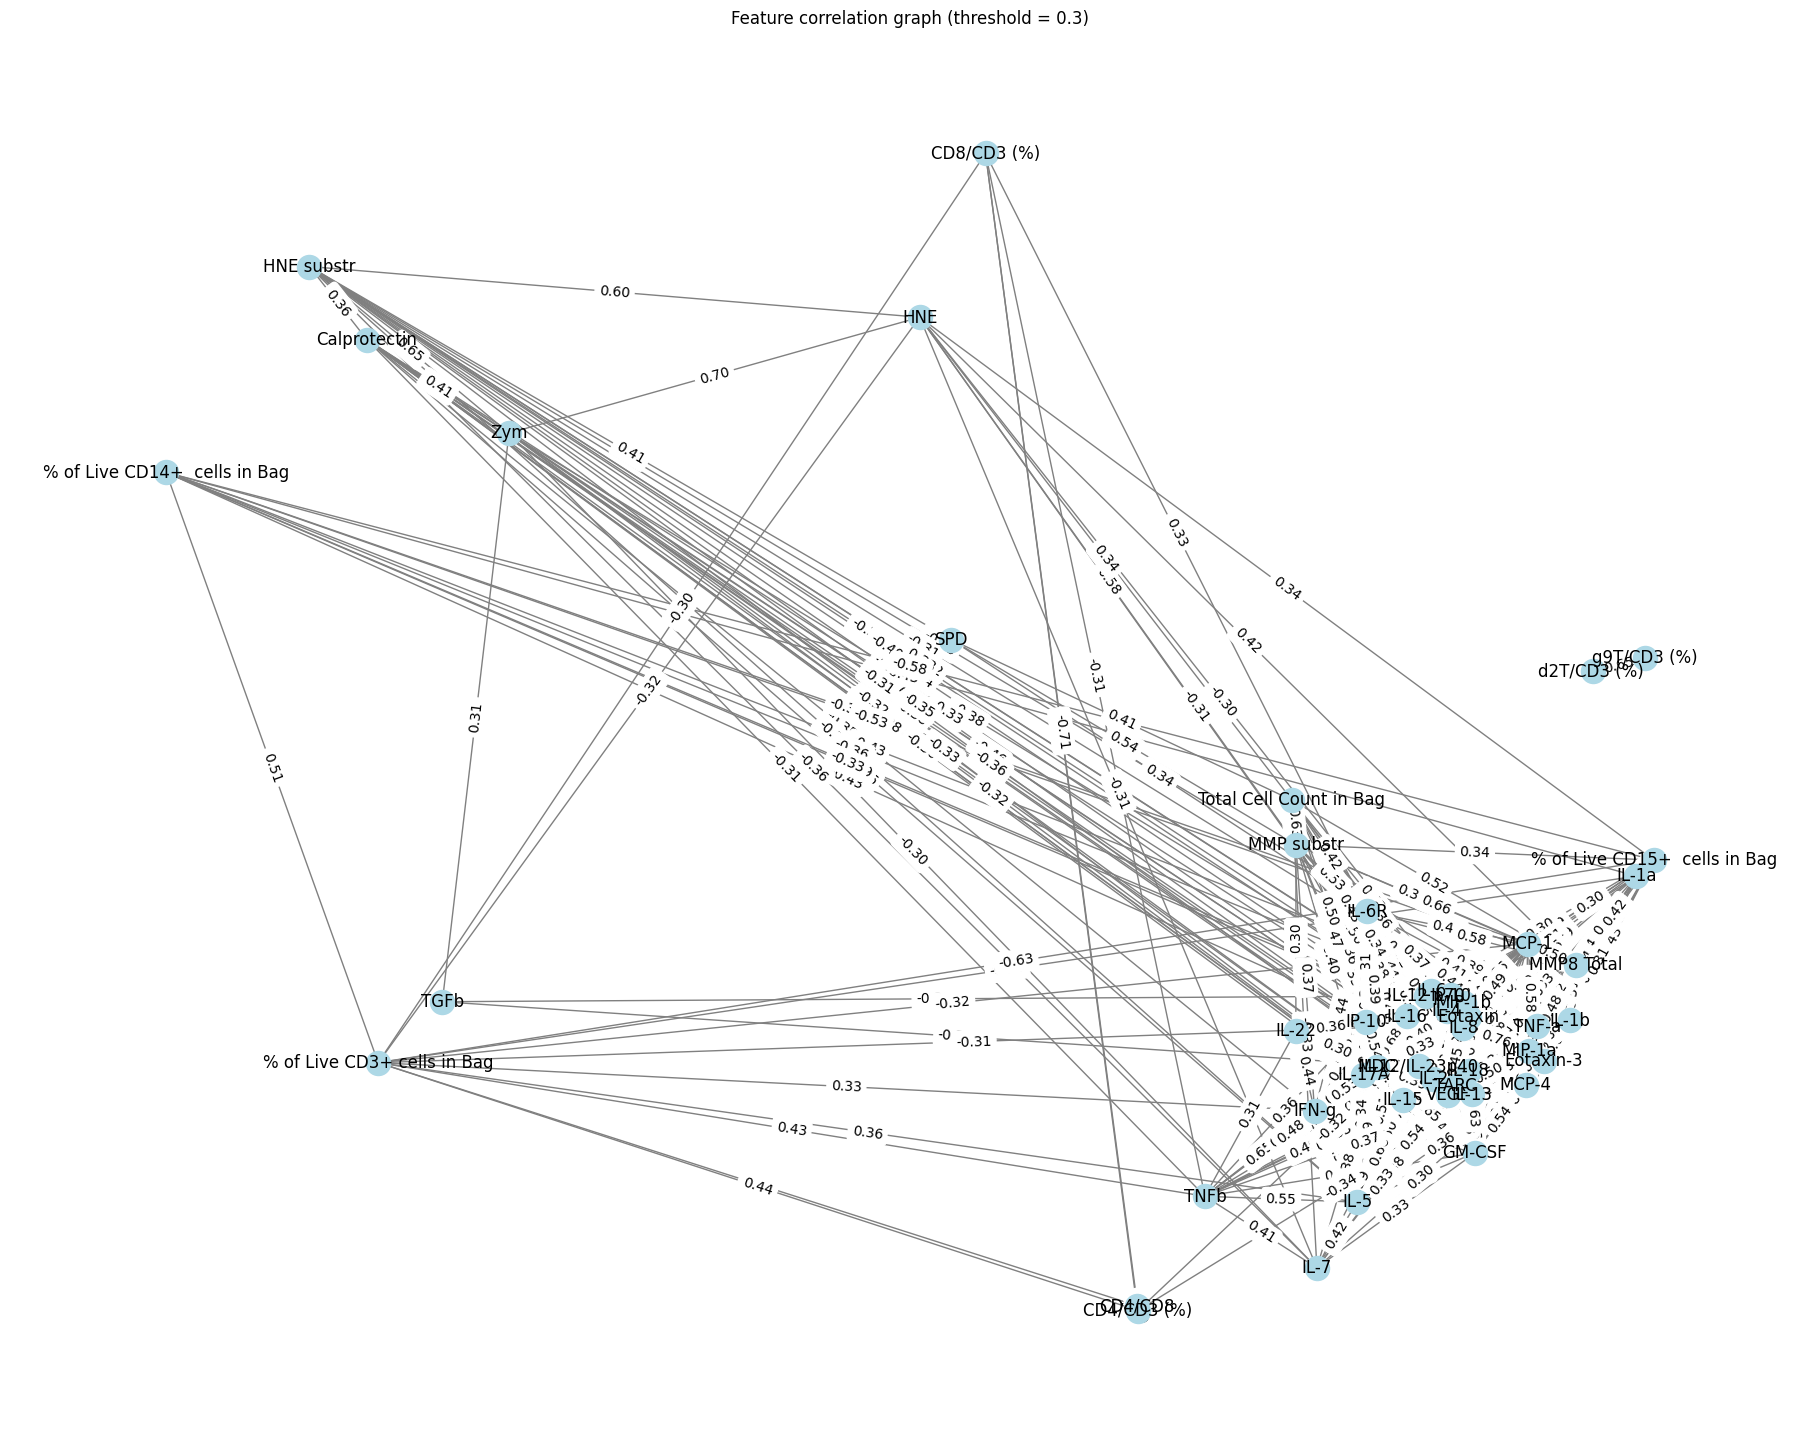

In [ ]:
without_gender = X_train.drop(columns=["Gender"], errors="ignore")
corr_matrix = without_gender.corr(method="spearman")

import networkx as nx

threshold = 0.3
G = nx.Graph()

for i, f1 in enumerate(corr_matrix.columns):
  for j, f2 in enumerate(corr_matrix.columns):
    if i < j:
      corr_val = corr_matrix.iloc[i, j]
      if abs(corr_val) > threshold:
        G.add_edge(f1, f2, weight=corr_val)

second_degree_pairs = []
for f1 in corr_matrix.columns:
  for f2 in corr_matrix.columns:
    if f1 != f2:
      try:
        path_len = nx.shortest_path_length(G, source=f1, target=f2)
        if path_len <= 2:
          second_degree_pairs.append((f1, f2, path_len))
      except nx.NetworkXNoPath:
          pass

plt.figure(figsize=(18, 14))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels={(u, v): f"{d['weight']:.2f}" for u,v,d in G.edges(data=True)})
plt.title("Feature correlation graph (threshold = 0.3)")
plt.show()

gg  Graph with 49 nodes and 473 edges


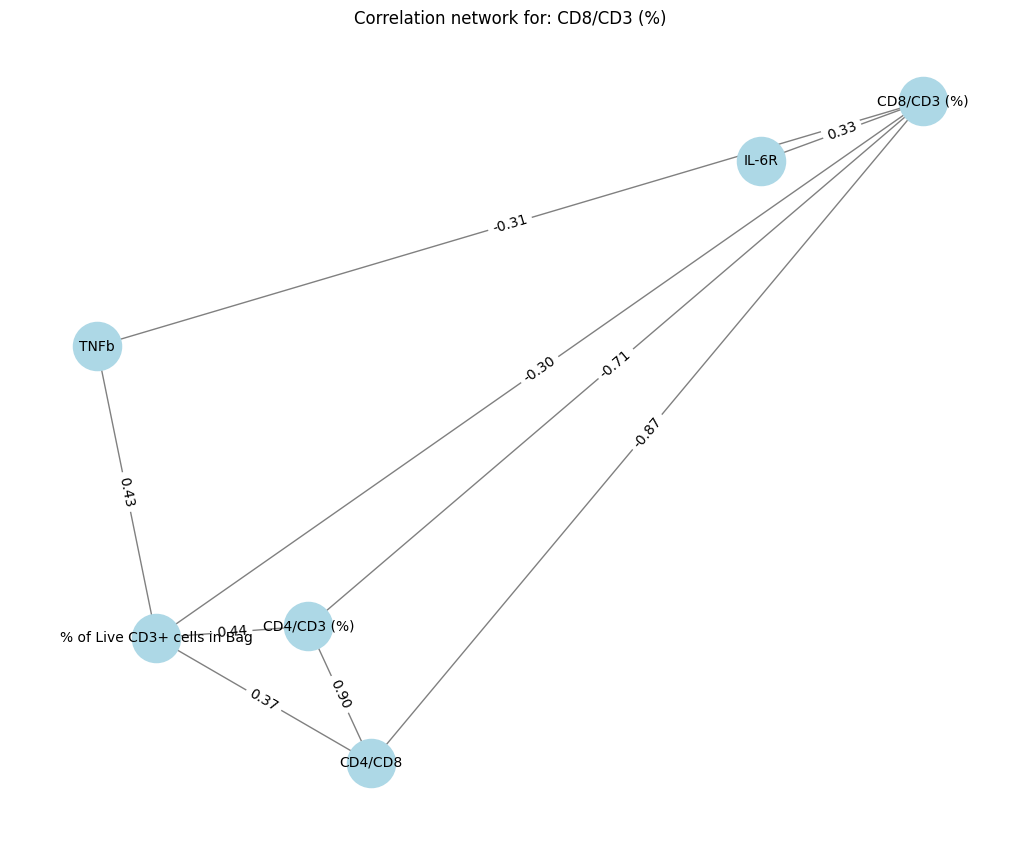

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx

print("gg ", G)
target_feature = "CD8/CD3 (%)"   # <<< change this to the feature you want

# Create an ego graph (1-hop neighbourhood)
ego = nx.ego_graph(G, target_feature, radius=1)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(ego, seed=42)

# Draw nodes + edges
nx.draw(
    ego, pos,
    with_labels=True,
    node_color='lightblue',
    edge_color='gray',
    node_size=1200,
    font_size=10
)

# Add edge labels (correlation values)
nx.draw_networkx_edge_labels(
    ego, pos,
    edge_labels={(u, v): f"{d['weight']:.2f}" for u, v, d in ego.edges(data=True)}
)

plt.title(f"Correlation network for: {target_feature}")
plt.show()

In [ ]:
import plotly.graph_objects as go
import networkx as nx

# 3D spring layout
pos_3d = nx.spring_layout(G, dim=3, seed=42)

# Extract node coordinates
x_nodes = [pos_3d[node][0] for node in G.nodes()]
y_nodes = [pos_3d[node][1] for node in G.nodes()]
z_nodes = [pos_3d[node][2] for node in G.nodes()]

# Extract edge coordinates
x_edges = []
y_edges = []
z_edges = []

for edge in G.edges():
    x_edges += [pos_3d[edge[0]][0], pos_3d[edge[1]][0], None]
    y_edges += [pos_3d[edge[0]][1], pos_3d[edge[1]][1], None]
    z_edges += [pos_3d[edge[0]][2], pos_3d[edge[1]][2], None]

# Create Plotly figure
fig = go.Figure()

# Add edges
fig.add_trace(go.Scatter3d(
    x=x_edges, y=y_edges, z=z_edges,
    mode='lines',
    line=dict(color='gray', width=2),
    hoverinfo='none'
))

# Add nodes
fig.add_trace(go.Scatter3d(
    x=x_nodes, y=y_nodes, z=z_nodes,
    mode='markers+text',
    marker=dict(size=8, color='lightblue'),
    text=list(G.nodes()),
    textposition="top center"
))

fig.update_layout(
    title="3D Feature Correlation Graph",
    showlegend=False,
    scene=dict(
        xaxis=dict(showbackground=False),
        yaxis=dict(showbackground=False),
        zaxis=dict(showbackground=False)
    )
)

fig.show()